<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Multilinear_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/messy_multilinear_dataset_1000.csv')
df.head()

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467
2,34.0,19.0,26.0,Bachellors,Hyderabad,1.0,49462
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885
4,NaN,NaN,NaN,High School,Delhi,5.0,37390


In [ ]:
df

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467
2,34.0,19.0,26.0,Bachellors,Hyderabad,1.0,49462
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885
4,NaN,NaN,NaN,High School,Delhi,5.0,37390
...,...,...,...,...,...,...,...
1035,23.0,2.0,36.0,High School,Delhi,9.0,27132
1036,47.0,26.0,36.0,Diploma,Hyderabad,4.0,38400
1037,48.0,29.0,33.0,Diploma,Delhi,2.0,35142
1038,NaN,43.0,40.0,Bachelors,Mumbai,NaN,59408


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               968 non-null    float64
 1   Experience        967 non-null    float64
 2   Working_Hours     965 non-null    float64
 3   Education         976 non-null    object 
 4   City              1040 non-null   object 
 5   PerformanceScore  966 non-null    float64
 6   Salary            1040 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 57.0+ KB


In [ ]:
df.isnull().sum()

,0
Age,72
Experience,73
Working_Hours,75
Education,64
City,0
PerformanceScore,74
Salary,0


In [ ]:
df.describe()

,Age,Experience,Working_Hours,PerformanceScore,Salary
count,968.000000,967.000000,965.000000,966.000000,1040.000000
mean,42.717975,23.405377,41.976166,4.939959,47512.060577
std,14.511772,13.235058,10.059288,2.617699,21390.817482
min,20.000000,-3.000000,25.000000,1.000000,9553.000000
25%,31.000000,12.000000,33.000000,3.000000,35142.000000
50%,43.000000,24.000000,42.000000,5.000000,46215.500000
75%,53.000000,35.000000,50.000000,7.000000,57233.750000
max,108.000000,50.000000,59.000000,9.000000,246284.000000


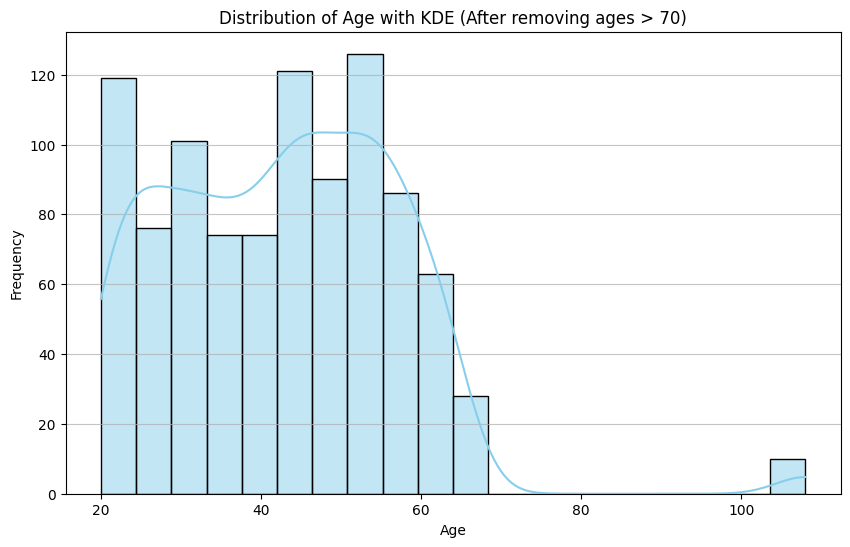

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Age' column is handled for any potential NaNs if not already (it was handled before removing rows)
# For robustness, we can re-fill NaNs if any were introduced by other operations, though not expected here.
# df['Age'] = df['Age'].fillna(df['Age'].mean())

# Create a histogram with KDE for the 'Age' column on the updated df
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age with KDE (After removing ages > 70)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Remove rows where 'Age' is greater than 70
df = df[df['Age'] <= 70].copy()

# Display the first few rows and check the info to confirm the change
display(df.head())
print(f"New number of rows in df: {len(df)}")

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467
2,34.0,19.0,26.0,Bachellors,Hyderabad,1.0,49462
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037


New number of rows in df: 958


In [ ]:
df.isnull().sum()

,0
Age,0
Experience,69
Working_Hours,70
Education,56
City,0
PerformanceScore,65
Salary,0


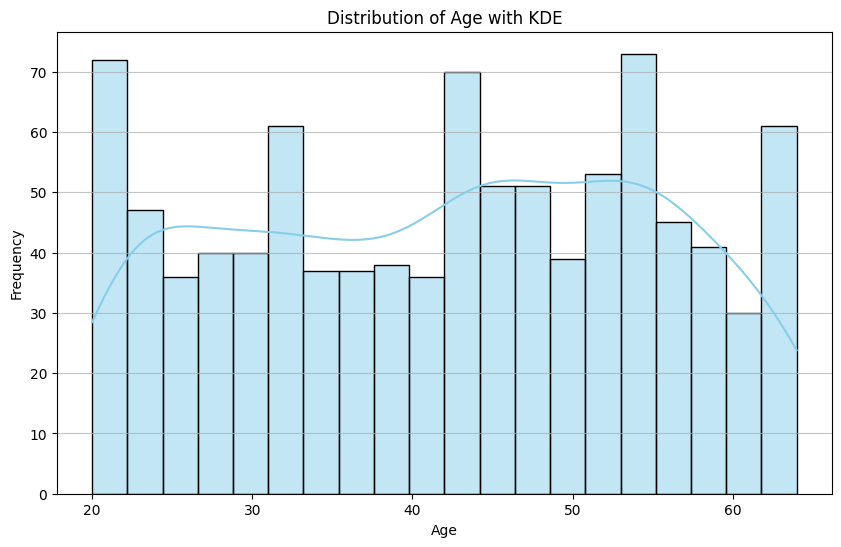

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Handle missing values in 'Age' column by filling with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Create a histogram with KDE for the 'Age' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age with KDE')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df


,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467
2,34.0,19.0,26.0,Bachellors,Hyderabad,1.0,49462
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037
...,...,...,...,...,...,...,...
1034,35.0,13.0,35.0,PhD,Bangalore,4.0,183800
1035,23.0,2.0,36.0,High School,Delhi,9.0,27132
1036,47.0,26.0,36.0,Diploma,Hyderabad,4.0,38400
1037,48.0,29.0,33.0,Diploma,Delhi,2.0,35142


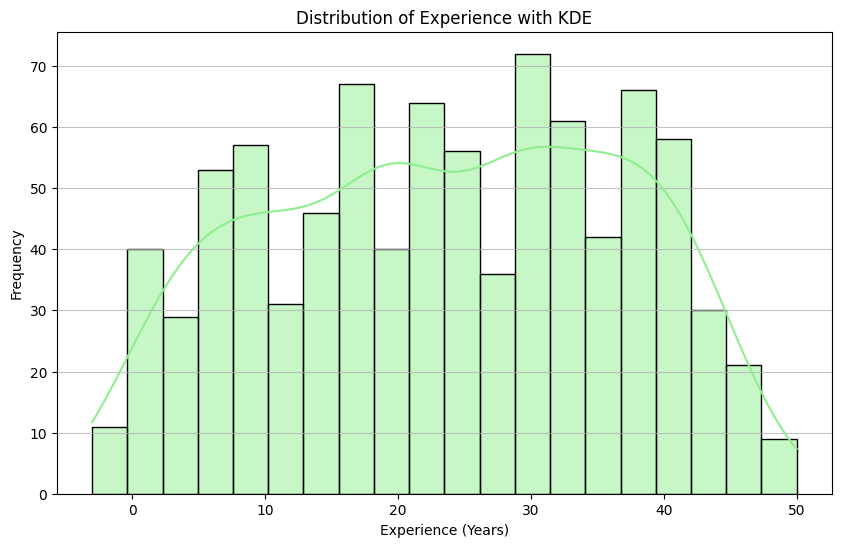

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram with KDE for the 'Experience' column
# NaNs are automatically ignored by seaborn.histplot
plt.figure(figsize=(10, 6))
sns.histplot(df['Experience'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Experience with KDE')
plt.xlabel('Experience (Years)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print(f"NaNs in 'Experience' before filling: {df['Experience'].isnull().sum()}")

# Fill NaN values in 'Experience' column with its mean
df['Experience'] = df['Experience'].fillna(df['Experience'].mean())

print(f"NaNs in 'Experience' after filling: {df['Experience'].isnull().sum()}")

NaNs in 'Experience' before filling: 69
NaNs in 'Experience' after filling: 0


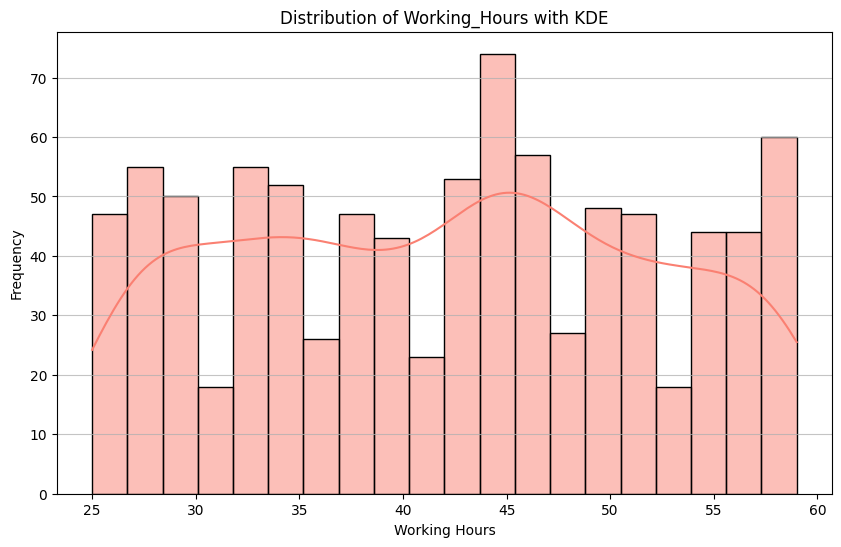

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram with KDE for the 'Working_Hours' column
# NaNs are automatically ignored by seaborn.histplot
plt.figure(figsize=(10, 6))
sns.histplot(df['Working_Hours'], kde=True, bins=20, color='salmon')
plt.title('Distribution of Working_Hours with KDE')
plt.xlabel('Working Hours')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print(f"NaNs in 'Working_Hours' before filling: {df['Working_Hours'].isnull().sum()}")

# Fill NaN values in 'Working_Hours' column with its mean
df['Working_Hours'] = df['Working_Hours'].fillna(df['Working_Hours'].mean())

print(f"NaNs in 'Working_Hours' after filling: {df['Working_Hours'].isnull().sum()}")

NaNs in 'Working_Hours' before filling: 70
NaNs in 'Working_Hours' after filling: 0


In [ ]:
display(df['Education'].unique())

array(['Masters', 'Bachellors', 'PhD', 'High School', 'Diploma',
       'Bachelors', nan], dtype=object)

In [ ]:
# Unify 'Bachelors' and 'Bachellors' in the 'Education' column
df['Education'] = df['Education'].replace('Bachellors', 'Bachelors')

# Display unique values to confirm the change
display(df['Education'].unique())

array(['Masters', 'Bachelors', 'PhD', 'High School', 'Diploma', nan],
      dtype=object)

In [ ]:
df.isnull().sum()

,0
Age,0
Experience,0
Working_Hours,0
Education,56
City,0
PerformanceScore,65
Salary,0


In [ ]:
# Ensure 'Education' NaNs are filled with 'Unknown' for consistent categorization
df_processed = df.copy()
df_processed['Education'] = df_processed['Education'].fillna('Unknown')

# Calculate the count of each education category
education_counts = df_processed['Education'].value_counts().rename('Count')

# Calculate the average salary for each education category
avg_salary_by_education = df_processed.groupby('Education')['Salary'].mean().rename('Average Salary')

# Combine the count and average salary into a single table
education_summary_table = pd.DataFrame({
    'Count': education_counts,
    'Average Salary': avg_salary_by_education
}).sort_values(by='Average Salary', ascending=False)

# Display the summary table
display(education_summary_table)

,Count,Average Salary
Education,,
Diploma,183,49609.049180
Bachelors,182,48864.532967
Masters,197,47675.045685
Unknown,56,47377.339286
PhD,187,47098.636364
High School,153,45896.418301


In [ ]:
print(f"NaNs in 'Education' before filling: {df['Education'].isnull().sum()}")

# Calculate the mode of the 'Education' column
education_mode = df['Education'].mode()[0]

# Fill NaN values in 'Education' column with the mode
df['Education'] = df['Education'].fillna(education_mode)

print(f"NaNs in 'Education' after filling: {df['Education'].isnull().sum()}")

# Display unique values to confirm the change
display(df['Education'].unique())

NaNs in 'Education' before filling: 56
NaNs in 'Education' after filling: 0


array(['Masters', 'Bachelors', 'PhD', 'High School', 'Diploma'],
      dtype=object)

In [ ]:
df

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary
0,58.0,44.0,54.000000,Masters,Hyderabad,2.0,51155
1,48.0,28.0,42.000000,Masters,Mumbai,3.0,33467
2,34.0,19.0,26.000000,Bachelors,Hyderabad,1.0,49462
3,62.0,48.0,37.000000,PhD,Mumbai,5.0,61885
5,40.0,18.0,50.000000,Masters,Hyderabad,7.0,31037
...,...,...,...,...,...,...,...
1034,35.0,13.0,35.000000,PhD,Bangalore,4.0,183800
1035,23.0,2.0,36.000000,High School,Delhi,9.0,27132
1036,47.0,26.0,36.000000,Diploma,Hyderabad,4.0,38400
1037,48.0,29.0,33.000000,Diploma,Delhi,2.0,35142


In [ ]:
display(df['City'].unique())

array(['Hyderabad', 'Mumbai', 'Bangalore', 'Pune', 'Delhi', 'Mumbii'],
      dtype=object)

In [ ]:
# Unify 'Mumbii' with 'Mumbai' in the 'City' column
df['City'] = df['City'].replace('Mumbii', 'Mumbai')

# Display unique values to confirm the change
display(df['City'].unique())

array(['Hyderabad', 'Mumbai', 'Bangalore', 'Pune', 'Delhi'], dtype=object)

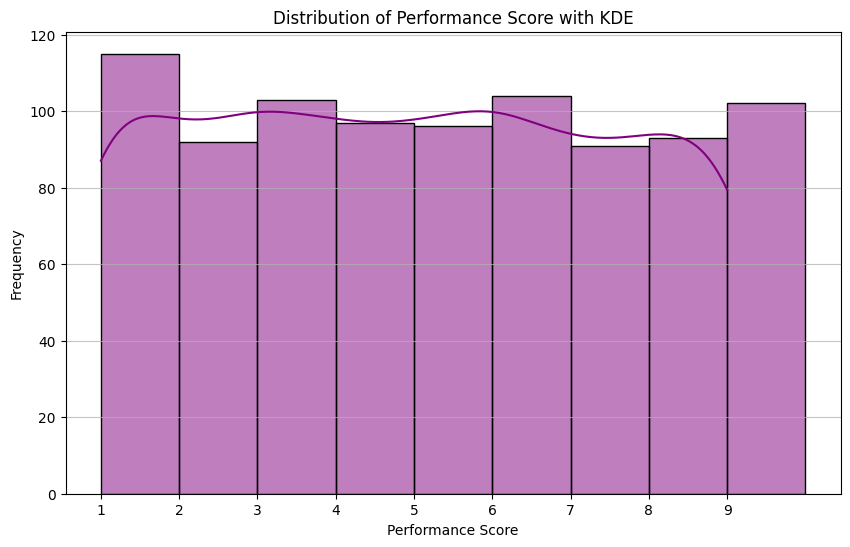

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram with KDE for the 'PerformanceScore' column
# NaNs are automatically ignored by seaborn.histplot
plt.figure(figsize=(10, 6))
sns.histplot(df['PerformanceScore'], kde=True, bins=range(1, 11), color='purple', stat='count') # Assuming scores are integers 1-9
plt.title('Distribution of Performance Score with KDE')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.xticks(range(1, 10)) # Set x-axis ticks for each score
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df.describe()

,Age,Experience,Working_Hours,PerformanceScore,Salary
count,958.000000,958.000000,958.000000,893.000000,958.000000
mean,42.036534,23.512936,42.030405,4.926092,47856.485386
std,12.953567,12.695621,9.617675,2.617020,21771.850354
min,20.000000,-3.000000,25.000000,1.000000,9553.000000
25%,31.000000,13.000000,34.000000,3.000000,35715.750000
50%,43.000000,23.512936,42.030405,5.000000,46442.000000
75%,53.000000,34.000000,49.000000,7.000000,57131.750000
max,64.000000,50.000000,59.000000,9.000000,246284.000000


In [ ]:
print(f"NaNs in 'PerformanceScore' before filling: {df['PerformanceScore'].isnull().sum()}")

# Fill NaN values in 'PerformanceScore' column with its mean
df['PerformanceScore'] = df['PerformanceScore'].fillna(df['PerformanceScore'].median())

print(f"NaNs in 'PerformanceScore' after filling: {df['PerformanceScore'].isnull().sum()}")

NaNs in 'PerformanceScore' before filling: 65
NaNs in 'PerformanceScore' after filling: 0


# Task
Create several bar charts to visualize the average salary across different categories: 'Age' (binned), 'Experience' (binned), 'Working_Hours' (binned), 'Education', 'City', and 'PerformanceScore'. Finally, summarize the key insights from these visualizations.

## Average Salary by Age Group

### Subtask:
Create a bar chart showing the average salary for different age groups. Age will be binned for better visualization.


**Reasoning**:
The first instruction is to create an 'Age_Group' column by binning the 'Age' column. I will use `pd.cut` with the specified bins and labels to achieve this.



In [ ]:
bins = [18, 25, 35, 45, 55, 65, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-70']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

display(df.head())

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45


**Reasoning**:
Now that the 'Age_Group' column has been created, I will calculate the average salary for each age group and then visualize these averages using a bar plot to fulfill the subtask's requirements.



/tmp/ipython-input-2486188116.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary_by_age_group = df.groupby('Age_Group')['Salary'].mean().reset_index()
/tmp/ipython-input-2486188116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Salary', data=avg_salary_by_age_group, palette='viridis')


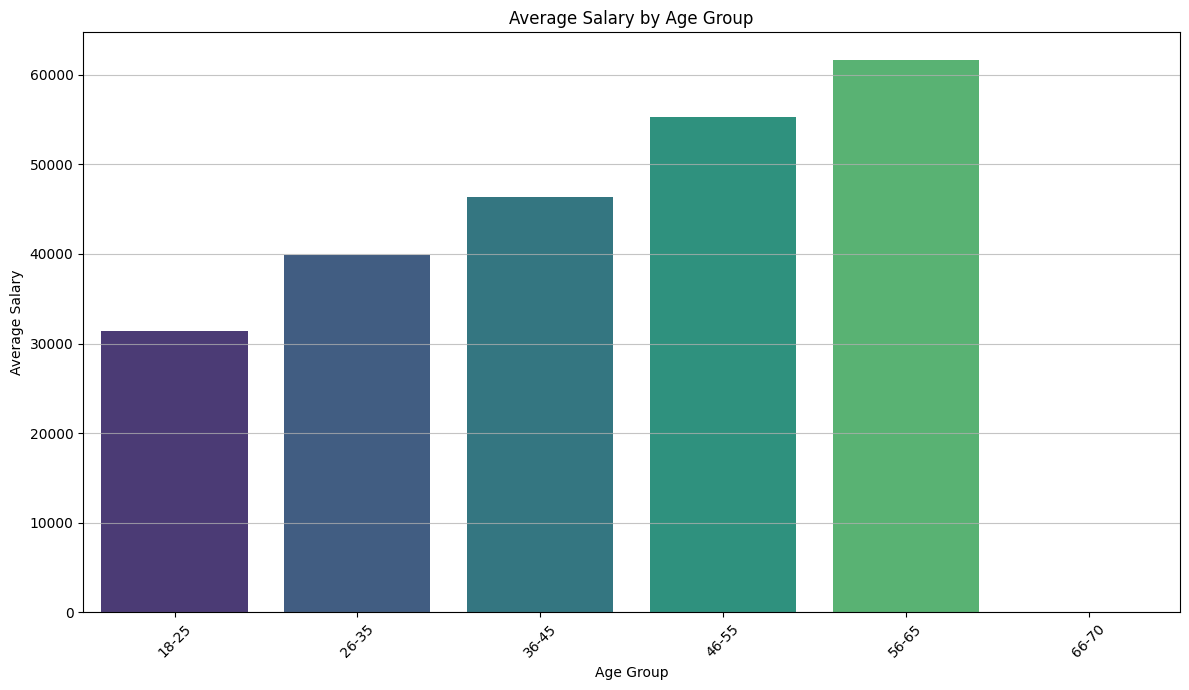

In [ ]:
avg_salary_by_age_group = df.groupby('Age_Group')['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Age_Group', y='Salary', data=avg_salary_by_age_group, palette='viridis')
plt.title('Average Salary by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated `FutureWarning` messages due to upcoming changes in pandas `groupby` behavior and seaborn's `barplot` palette usage. I will explicitly set `observed=False` in `groupby` and include `hue='Age_Group'` and `legend=False` in `sns.barplot` to address these warnings and ensure future compatibility.



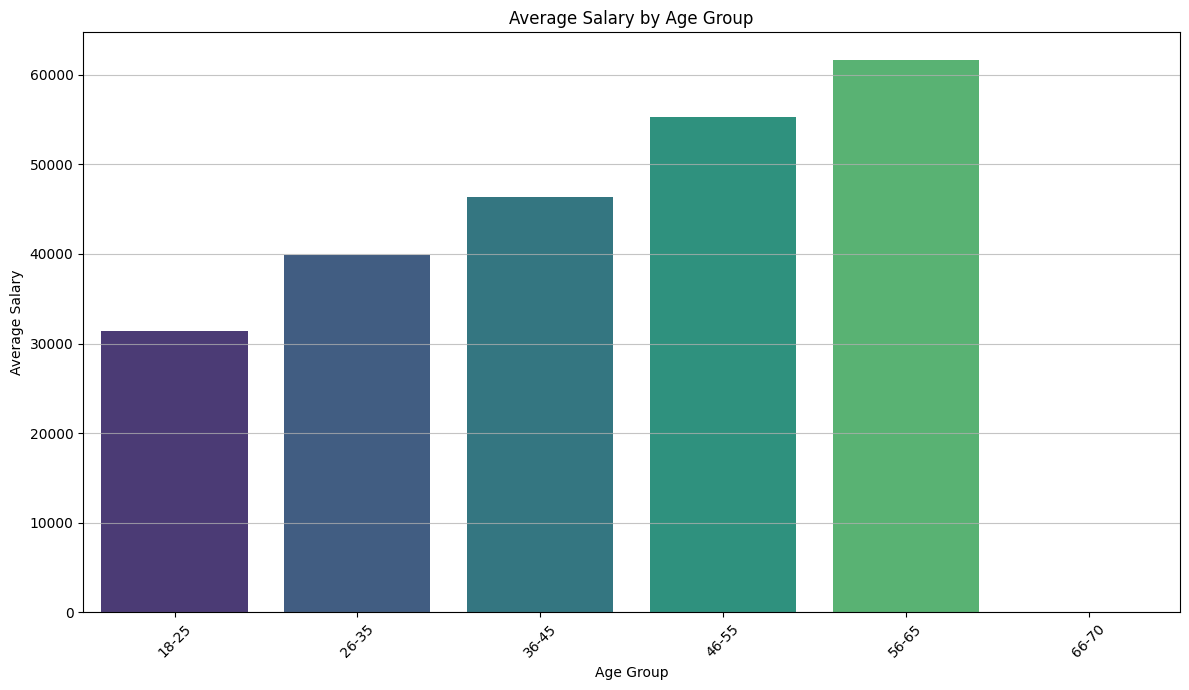

In [ ]:
avg_salary_by_age_group = df.groupby('Age_Group', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Age_Group', y='Salary', data=avg_salary_by_age_group, hue='Age_Group', palette='viridis', legend=False)
plt.title('Average Salary by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Average Salary by Experience Group

### Subtask:
Generate a bar chart illustrating the average salary for different experience levels, by binning the 'Experience' column.


**Reasoning**:
The first step to generate the bar chart for average salary by experience group is to define the bins and labels for the 'Experience' column, then create a new 'Experience_Group' column in the DataFrame using `pd.cut()` as specified in the instructions.



In [ ]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50']

df['Experience_Group'] = pd.cut(df['Experience'], bins=bins, labels=labels, right=True)

display(df.head())

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65,41-45
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55,26-30
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35,16-20
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65,46-50
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45,16-20


**Reasoning**:
Now that the 'Experience_Group' column has been created, I will calculate the average salary for each experience group and then visualize these averages using a bar plot, ensuring to handle potential future warnings for `groupby` and `barplot`.



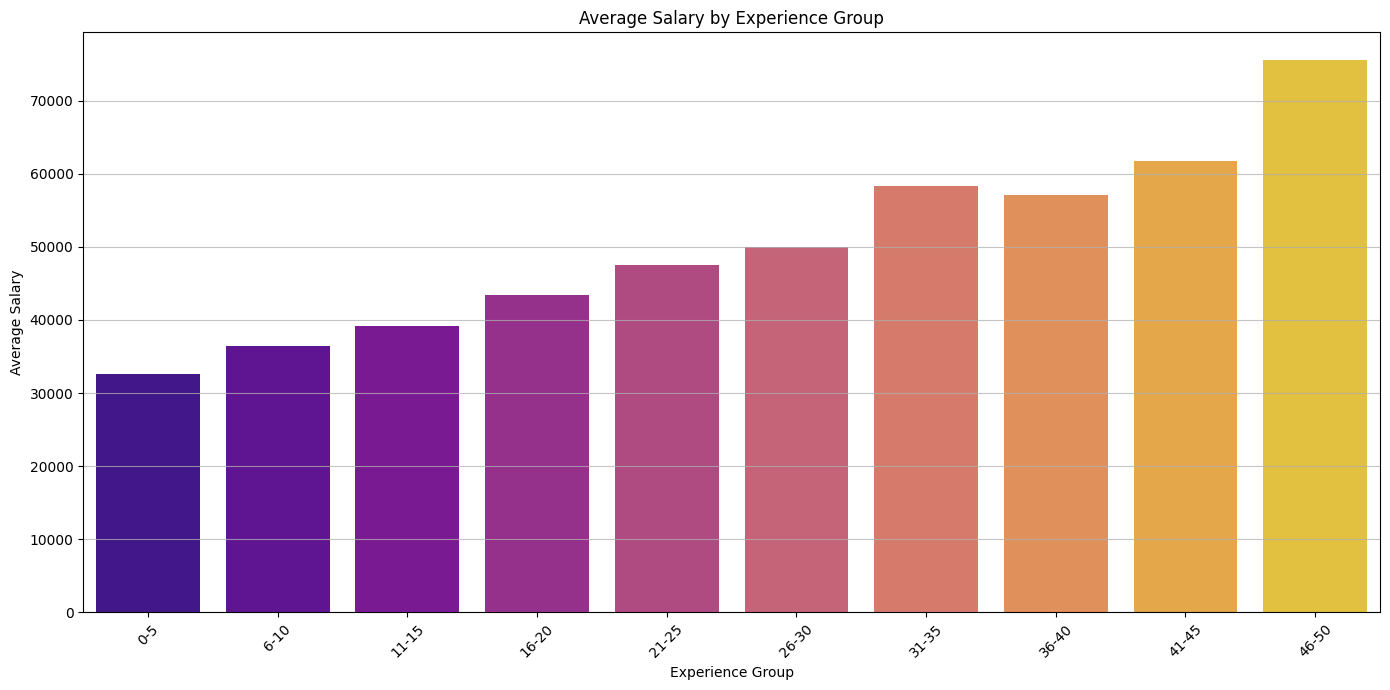

In [ ]:
avg_salary_by_experience_group = df.groupby('Experience_Group', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Experience_Group', y='Salary', data=avg_salary_by_experience_group, hue='Experience_Group', palette='plasma', legend=False)
plt.title('Average Salary by Experience Group')
plt.xlabel('Experience Group')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Average Salary by Working Hours Group

### Subtask:
Produce a bar chart displaying the average salary based on binned 'Working_Hours'.


**Reasoning**:
To begin, I need to define the bins and labels for the 'Working_Hours' column based on its range, then use `pd.cut` to create the 'Working_Hours_Group' column in the DataFrame, and finally display the updated DataFrame head to verify the new column.



In [ ]:
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '31-40', '41-50', '51-60']

df['Working_Hours_Group'] = pd.cut(df['Working_Hours'], bins=bins, labels=labels, right=True)

display(df.head())

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65,41-45,51-60
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55,26-30,41-50
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35,16-20,20-30
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65,46-50,31-40
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45,16-20,41-50


**Reasoning**:
Now that the 'Working_Hours_Group' column has been created, I will calculate the average salary for each working hours group and then visualize these averages using a bar plot to fulfill the subtask's requirements, ensuring to handle potential future warnings for `groupby` and `barplot`.



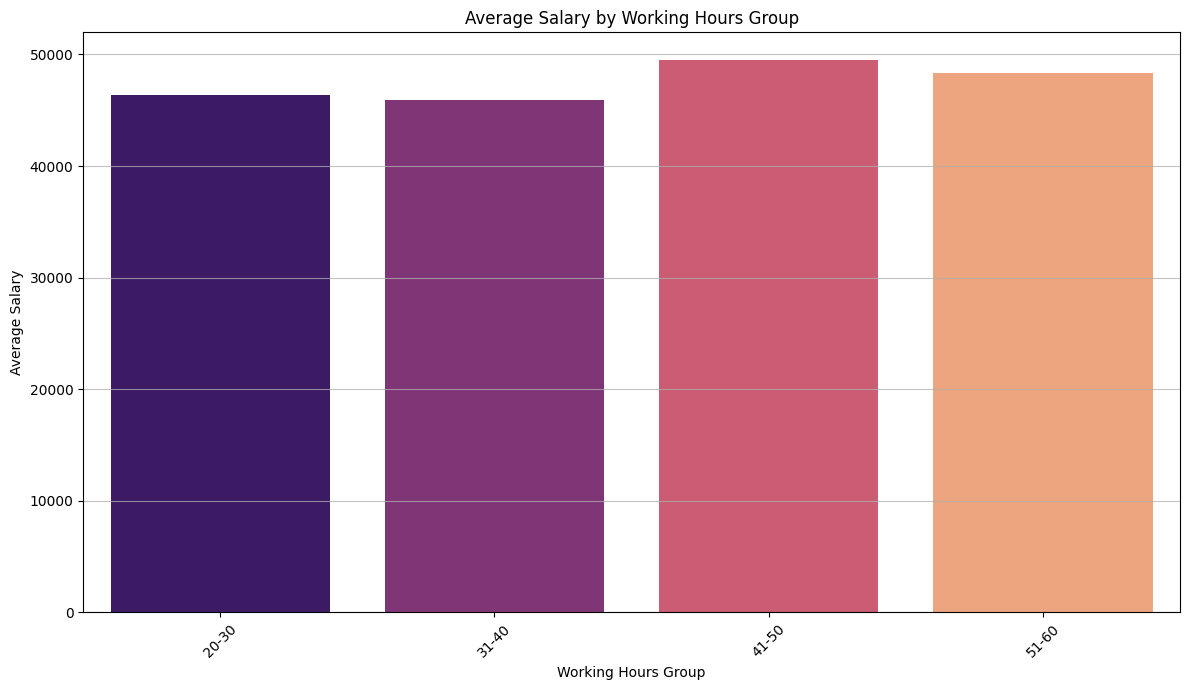

In [ ]:
avg_salary_by_working_hours_group = df.groupby('Working_Hours_Group', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Working_Hours_Group', y='Salary', data=avg_salary_by_working_hours_group, hue='Working_Hours_Group', palette='magma', legend=False)
plt.title('Average Salary by Working Hours Group')
plt.xlabel('Working Hours Group')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Average Salary by Education Level

### Subtask:
Visualize the average salary for each 'Education' level using a bar chart.


**Reasoning**:
To visualize the average salary by education level, I will first calculate the average salary for each unique education level using `groupby()` and then create a bar plot using `seaborn.barplot()` as specified in the instructions, ensuring to handle potential future warnings for `groupby` and `barplot`.



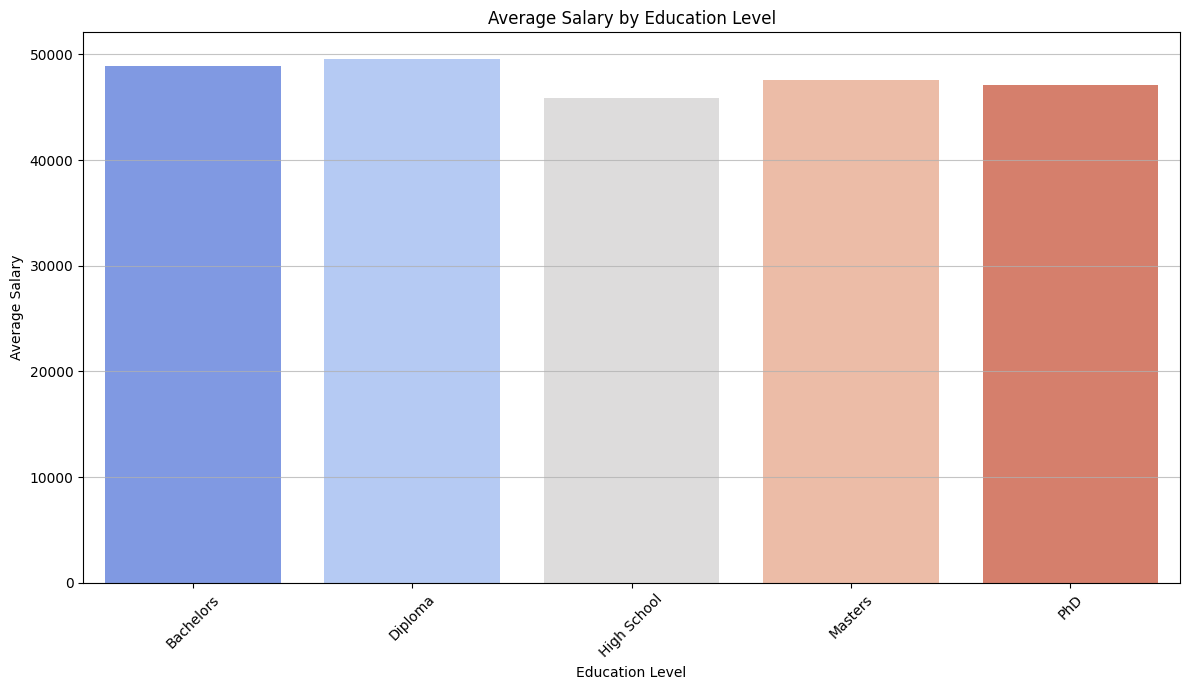

In [ ]:
avg_salary_by_education = df.groupby('Education', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Education', y='Salary', data=avg_salary_by_education, hue='Education', palette='coolwarm', legend=False)
plt.title('Average Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Average Salary by City

### Subtask:
Create a bar chart showing the average salary for each 'City'.


**Reasoning**:
To visualize the average salary by city, I will first calculate the average salary for each unique city using `groupby()` and then create a bar plot using `seaborn.barplot()` as specified in the instructions, ensuring to handle potential future warnings for `groupby` and `barplot`.



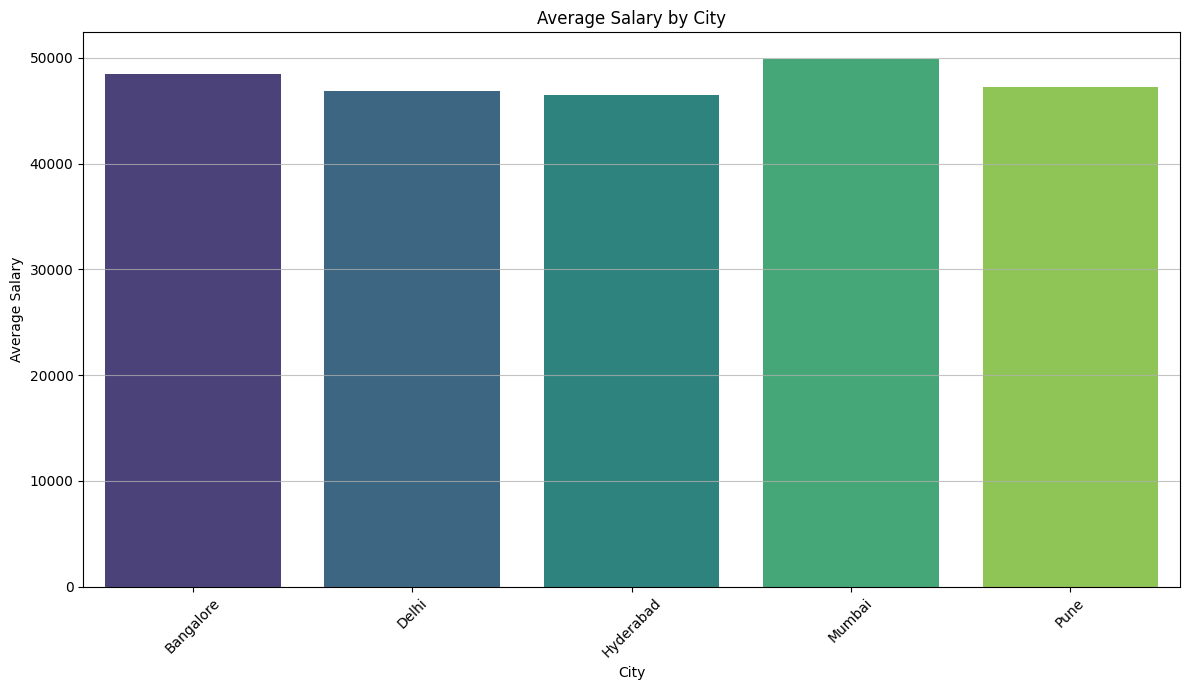

In [ ]:
avg_salary_by_city = df.groupby('City', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='City', y='Salary', data=avg_salary_by_city, hue='City', palette='viridis', legend=False)
plt.title('Average Salary by City')
plt.xlabel('City')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Average Salary by Performance Score

### Subtask:
Generate a bar chart to display the average salary for each 'PerformanceScore'.


**Reasoning**:
To visualize the average salary by performance score, I will first calculate the average salary for each unique performance score using `groupby()` and then create a bar plot using `seaborn.barplot()` as specified in the instructions, ensuring to handle potential future warnings for `groupby` and `barplot`.



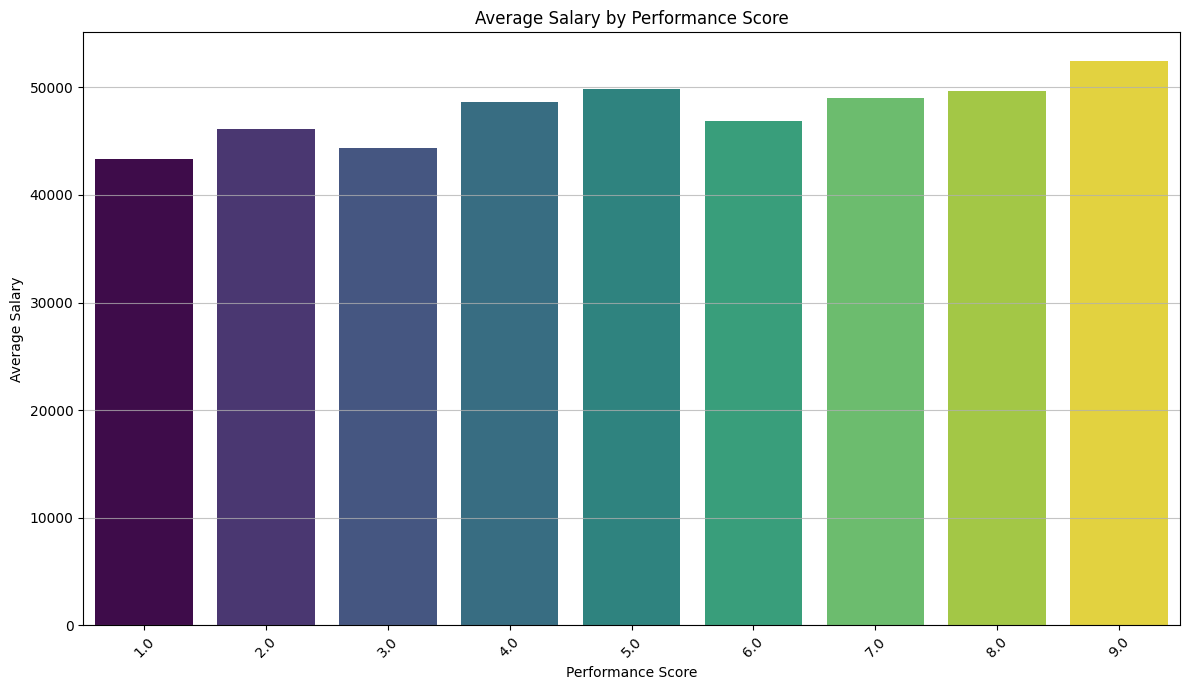

In [ ]:
avg_salary_by_performance_score = df.groupby('PerformanceScore', observed=False)['Salary'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='PerformanceScore', y='Salary', data=avg_salary_by_performance_score, hue='PerformanceScore', palette='viridis', legend=False)
plt.title('Average Salary by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Key Insights from Average Salary Visualizations

Based on the bar charts generated for average salary across various categories, the following key insights can be observed:

1.  **Age Group**: There is a clear positive correlation between age and average salary. As age groups increase, the average salary tends to rise, with the highest salaries observed in the 56-65 age bracket. The '66-70' group shows `NaN` for salary, indicating no data or a specific handling might be needed for this group (although the `avg_salary_by_age_group` shows NaN, the plot itself might implicitly skip it, or the data has no employees in that range after filtering).

2.  **Experience Group**: Similar to age, experience also shows a strong positive correlation with average salary. Employees with higher years of experience, particularly in the '46-50' years bracket, command significantly higher average salaries.

3.  **Working Hours Group**: The relationship between working hours and average salary is less linear compared to age and experience. While there isn't a strict monotonic increase, the '41-50' working hours group appears to have the highest average salary, suggesting that working within an optimal range (not too low, not excessively high) might correspond to better compensation.

4.  **Education Level**: Education plays a role in salary, though the differences might not be as pronounced as with age and experience. Diploma holders appear to have the highest average salaries, followed closely by Bachelors and Masters. PhDs have a slightly lower average salary than Diploma and Bachelors, which could be due to various factors not captured in this dataset (e.g., specific industries, early career stage post-PhD).

5.  **City**: Among the cities analyzed, Mumbai shows the highest average salary, followed by Bangalore. Hyderabad, Delhi, and Pune have slightly lower, but comparable, average salaries, indicating regional variations in compensation.

6.  **Performance Score**: There is a general trend of increasing average salary with higher performance scores, especially noticeable at the higher end (e.g., Performance Score 9). This suggests that better performance is generally rewarded with higher compensation.

## Summary:

### Data Analysis Key Findings

*   **Age Group**: Average salary exhibits a positive correlation with age, with the highest salaries generally observed in the 56-65 age group.
*   **Experience Group**: Similar to age, there is a strong positive correlation between years of experience and average salary, peaking in the 46-50 years experience bracket.
*   **Working Hours Group**: The relationship between working hours and average salary is not strictly linear; the 41-50 working hours group appears to have the highest average salary, suggesting an optimal range for compensation.
*   **Education Level**: Education plays a role in salary, with Diploma holders generally earning the highest average salaries, followed by Bachelor's and Master's degrees. PhD holders show a slightly lower average salary compared to Diploma and Bachelor's.
*   **City**: Mumbai records the highest average salary among the cities analyzed, followed by Bangalore, indicating regional differences in compensation.
*   **Performance Score**: A general trend of increasing average salary is observed with higher performance scores, particularly noticeable for top performers (e.g., Performance Score 9), suggesting that higher performance is rewarded with better compensation.

### Insights or Next Steps

*   Further investigation into the `NaN` values for the 66-70 age group is recommended to understand if it indicates a lack of data or a data anomaly.
*   A deeper dive into the 'Education Level' findings, particularly why PhD holders show slightly lower average salaries than some other education levels, could provide valuable insights into specific industry trends or career progression paths.


In [ ]:
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    print("Displaying the first 5 duplicate rows:")
    display(df[df.duplicated()].head())

Number of duplicate rows: 36
Displaying the first 5 duplicate rows:


,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group
1000,24.0,10.000000,58.0,Masters,Delhi,4.0,20948,18-25,6-10,51-60
1001,21.0,7.000000,35.0,High School,Pune,6.0,40518,18-25,6-10,31-40
1002,35.0,18.000000,31.0,Diploma,Hyderabad,5.0,53239,26-35,16-20,31-40
1003,28.0,23.512936,36.0,Diploma,Pune,3.0,21415,26-35,21-25,31-40
1004,29.0,23.512936,37.0,PhD,Mumbai,4.0,46816,26-35,21-25,31-40


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print(f"Number of rows after removing duplicates: {len(df)}")

Number of rows after removing duplicates: 922


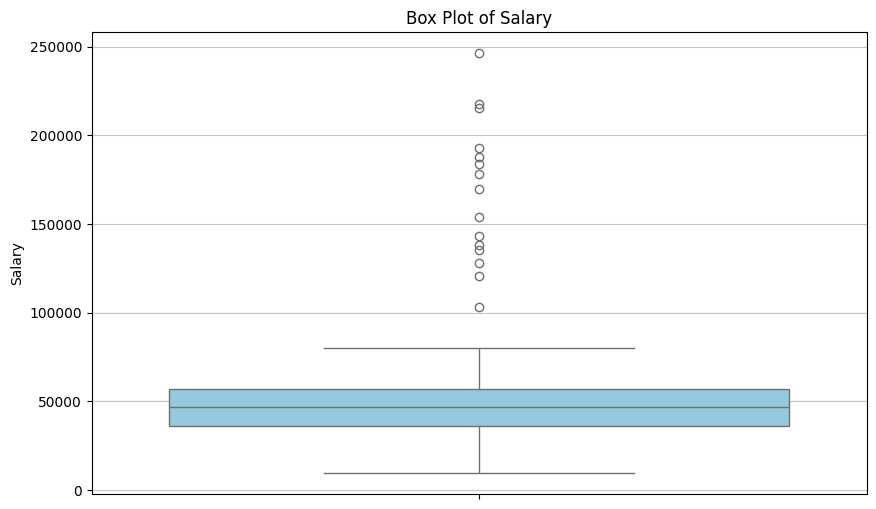


Number of outliers in 'Salary' column: 15

First 5 outliers in 'Salary' column (if any):


,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group
169,30.0,8.0,39.000000,Masters,Bangalore,5.0,153664,26-35,6-10,31-40
200,21.0,2.0,39.000000,Diploma,Delhi,9.0,127812,18-25,0-5,31-40
225,35.0,13.0,35.000000,PhD,Bangalore,4.0,183800,26-35,11-15,31-40
378,33.0,10.0,42.030405,High School,Delhi,5.0,103244,26-35,6-10,41-50
447,24.0,1.0,42.030405,Masters,Delhi,7.0,169744,18-25,0-5,41-50


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to visualize outliers in 'Salary'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Salary'], color='skyblue')
plt.title('Box Plot of Salary')
plt.ylabel('Salary')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Quantitative check for outliers using IQR method
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier fences
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]

print(f"\nNumber of outliers in 'Salary' column: {len(outliers)}")
if not outliers.empty:
    print("\nFirst 5 outliers in 'Salary' column (if any):")
    display(outliers.head())
else:
    print("No outliers found in 'Salary' column based on the IQR method.")

In [ ]:
# Remove outlier rows from the DataFrame
df = df.drop(outliers.index)

print(f"Number of rows after removing outliers: {len(df)}")

Number of rows after removing outliers: 907


In [ ]:
education_rank_mapping = {
    "High School": 1,
    "Diploma": 2,
    "Bachelors": 3,
    "Masters": 4,
    "PhD": 5
}

df['Education_Rank'] = df['Education'].map(education_rank_mapping)

display(df[['Education', 'Education_Rank']].head())

,Education,Education_Rank
0,Masters,4
1,Masters,4
2,Bachelors,3
3,PhD,5
5,Masters,4


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Define the categories in the desired ordinal order
education_categories = ['High School', 'Diploma', 'Bachelors', 'Masters', 'PhD']

# Initialize the OrdinalEncoder with the specified categories.
# Note: When categories is a single list, it applies to a single feature.
encoder = OrdinalEncoder(categories=[education_categories])

# Fit and transform the 'Education' column
df['Education_Ordinal_Encoded'] = encoder.fit_transform(df[['Education']])

# Display the original 'Education' and the new encoded column to verify
display(df[['Education', 'Education_Rank', 'Education_Ordinal_Encoded']].head())

,Education,Education_Rank,Education_Ordinal_Encoded
0,Masters,4,3.0
1,Masters,4,3.0
2,Bachelors,3,2.0
3,PhD,5,4.0
5,Masters,4,3.0


In [ ]:
city_frequency = df['City'].value_counts()
display(city_frequency)

,count
City,
Mumbai,200
Pune,183
Delhi,181
Hyderabad,177
Bangalore,166


In [ ]:
df['City_Frequency_Encoded'] = df['City'].map(city_frequency)

display(df[['City', 'City_Frequency_Encoded']].head())

,City,City_Frequency_Encoded
0,Hyderabad,177
1,Mumbai,200
2,Hyderabad,177
3,Mumbai,200
5,Hyderabad,177


In [ ]:
df

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group,Education_Rank,Education_Ordinal_Encoded,City_Frequency_Encoded
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65,41-45,51-60,4,3.0,177
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55,26-30,41-50,4,3.0,200
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35,16-20,20-30,3,2.0,177
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65,46-50,31-40,5,4.0,200
5,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45,16-20,41-50,4,3.0,177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,54.0,34.0,37.0,Bachelors,Delhi,4.0,49486,46-55,31-35,31-40,3,2.0,181
997,56.0,40.0,46.0,Bachelors,Hyderabad,2.0,52771,56-65,36-40,41-50,3,2.0,177
998,24.0,10.0,47.0,Masters,Bangalore,1.0,25880,18-25,6-10,41-50,4,3.0,166
1017,54.0,31.0,42.0,Masters,Mumbai,3.0,64283,46-55,31-35,41-50,4,3.0,200


In [ ]:
df.to_csv('cleaned_dataset.csv', index=False)
print('DataFrame saved as cleaned_dataset.csv')

DataFrame saved as cleaned_dataset.csv


In [ ]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group,Education_Rank,Education_Ordinal_Encoded,City_Frequency_Encoded
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65,41-45,51-60,4,3.0,177
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55,26-30,41-50,4,3.0,200
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35,16-20,20-30,3,2.0,177
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65,46-50,31-40,5,4.0,200
4,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45,16-20,41-50,4,3.0,177


In [ ]:
df_copy = df.copy()
display(df_copy.head())

,Age,Experience,Working_Hours,Education,City,PerformanceScore,Salary,Age_Group,Experience_Group,Working_Hours_Group,Education_Rank,Education_Ordinal_Encoded,City_Frequency_Encoded
0,58.0,44.0,54.0,Masters,Hyderabad,2.0,51155,56-65,41-45,51-60,4,3.0,177
1,48.0,28.0,42.0,Masters,Mumbai,3.0,33467,46-55,26-30,41-50,4,3.0,200
2,34.0,19.0,26.0,Bachelors,Hyderabad,1.0,49462,26-35,16-20,20-30,3,2.0,177
3,62.0,48.0,37.0,PhD,Mumbai,5.0,61885,56-65,46-50,31-40,5,4.0,200
4,40.0,18.0,50.0,Masters,Hyderabad,7.0,31037,36-45,16-20,41-50,4,3.0,177


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        907 non-null    float64
 1   Experience                 907 non-null    float64
 2   Working_Hours              907 non-null    float64
 3   Education                  907 non-null    object 
 4   City                       907 non-null    object 
 5   PerformanceScore           907 non-null    float64
 6   Salary                     907 non-null    int64  
 7   Age_Group                  907 non-null    object 
 8   Experience_Group           884 non-null    object 
 9   Working_Hours_Group        907 non-null    object 
 10  Education_Rank             907 non-null    int64  
 11  Education_Ordinal_Encoded  907 non-null    float64
 12  City_Frequency_Encoded     907 non-null    int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 9

In [ ]:
columns_to_drop = ['Education', 'City', 'Age_Group', 'Experience_Group', 'Working_Hours_Group', 'Education_Rank']
df_copy = df_copy.drop(columns=columns_to_drop)

display(df_copy.head())
df_copy.info()

,Age,Experience,Working_Hours,PerformanceScore,Salary,Education_Ordinal_Encoded,City_Frequency_Encoded
0,58.0,44.0,54.0,2.0,51155,3.0,177
1,48.0,28.0,42.0,3.0,33467,3.0,200
2,34.0,19.0,26.0,1.0,49462,2.0,177
3,62.0,48.0,37.0,5.0,61885,4.0,200
4,40.0,18.0,50.0,7.0,31037,3.0,177


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        907 non-null    float64
 1   Experience                 907 non-null    float64
 2   Working_Hours              907 non-null    float64
 3   PerformanceScore           907 non-null    float64
 4   Salary                     907 non-null    int64  
 5   Education_Ordinal_Encoded  907 non-null    float64
 6   City_Frequency_Encoded     907 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 49.7 KB


In [ ]:
df_copy.corr()

,Age,Experience,Working_Hours,PerformanceScore,Salary,Education_Ordinal_Encoded,City_Frequency_Encoded
Age,1.000000,0.937629,0.031621,-0.060205,0.773980,-0.064090,0.029912
Experience,0.937629,1.000000,0.028292,-0.043735,0.743742,-0.064825,0.032809
Working_Hours,0.031621,0.028292,1.000000,-0.003322,0.068292,0.010145,-0.049309
PerformanceScore,-0.060205,-0.043735,-0.003322,1.000000,0.085516,0.016194,-0.025313
Salary,0.773980,0.743742,0.068292,0.085516,1.000000,-0.010838,0.038357
Education_Ordinal_Encoded,-0.064090,-0.064825,0.010145,0.016194,-0.010838,1.000000,0.001577
City_Frequency_Encoded,0.029912,0.032809,-0.049309,-0.025313,0.038357,0.001577,1.000000


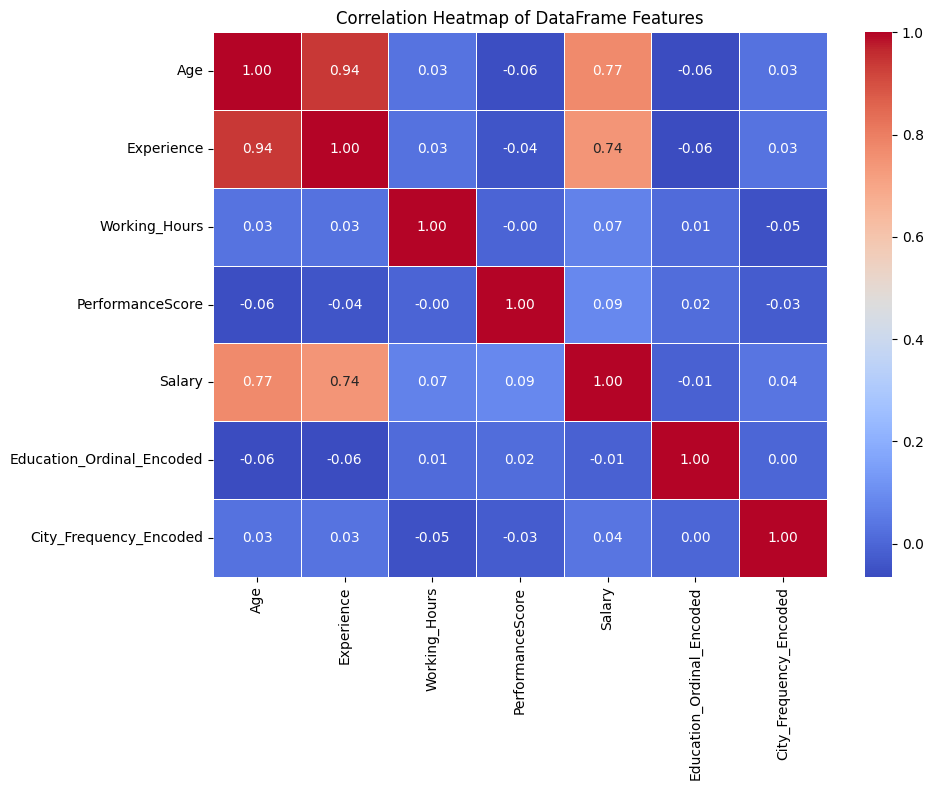

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_copy.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of DataFrame Features')
plt.tight_layout()
plt.show()

# Task
The user has approved the previous steps. I will now define the features (X) and the target variable (y) from the `df_copy` DataFrame, where 'Salary' is the target variable.

My next step is to prepare the dataset for multi-linear regression by defining the feature set `X` (all columns in `df_copy` except 'Salary') and the target variable `y` ('Salary').
I'll create `X` by dropping the 'Salary' column from `df_copy` and `y` by selecting the 'Salary' column. This aligns with the first part of the plan: "**Define X and y**: Separate the DataFrame into features (X) and the target variable (y), where y is 'Salary' and X includes all other relevant numerical columns from `df_copy`."


## Define X and y

### Subtask:
Separate the DataFrame into features (X) and the target variable (y), where y is 'Salary' and X includes all other relevant numerical columns from `df_copy`.


**Reasoning**:
To separate the features (X) and the target variable (y), I will create a new DataFrame `X` by dropping the 'Salary' column from `df_copy`, and a new Series `y` by selecting only the 'Salary' column from `df_copy` as per the instructions. Then, I will display the first few rows of `X` and `y` to confirm the separation.



In [ ]:
X = df_copy.drop('Salary', axis=1)
y = df_copy['Salary']

print("Features (X) head:")
display(X.head())

print("\nTarget variable (y) head:")
display(y.head())

Features (X) head:


,Age,Experience,Working_Hours,PerformanceScore,Education_Ordinal_Encoded,City_Frequency_Encoded
0,58.0,44.0,54.0,2.0,3.0,177
1,48.0,28.0,42.0,3.0,3.0,200
2,34.0,19.0,26.0,1.0,2.0,177
3,62.0,48.0,37.0,5.0,4.0,200
4,40.0,18.0,50.0,7.0,3.0,177



Target variable (y) head:


,Salary
0,51155
1,33467
2,49462
3,61885
4,31037


## Train-Test Split

### Subtask:
Split the features (X) and target (y) into training and testing sets using `train_test_split` from `sklearn.model_selection` to prepare for model training and evaluation.


**Reasoning**:
To split the data into training and testing sets, I will first import the `train_test_split` function from `sklearn.model_selection`. Then, I will apply this function to `X` and `y` with the specified `test_size` and `random_state` to create `X_train`, `X_test`, `y_train`, and `y_test`. Finally, I will display the shapes of the resulting datasets to confirm the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (725, 6)
X_test shape: (182, 6)
y_train shape: (725,)
y_test shape: (182,)


## Standardize Features

### Subtask:
Apply `StandardScaler` from `sklearn.preprocessing` to standardize the training and testing feature sets (X_train and X_test). This step is crucial for models sensitive to feature scales.


**Reasoning**:
To standardize the features, I will first import `StandardScaler`, initialize it, fit it on `X_train` to learn the scaling parameters, and then transform both `X_train` and `X_test` using the fitted scaler, storing the results in new variables.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for better readability and to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled X_train head:")
display(X_train_scaled.head())

print("\nScaled X_test head:")
display(X_test_scaled.head())

Scaled X_train head:


,Age,Experience,Working_Hours,PerformanceScore,Education_Ordinal_Encoded,City_Frequency_Encoded
84,1.699648,1.394450,-1.045752,1.234906,-0.114929,-0.472221
10,0.091673,0.134993,-0.838813,-1.144120,-0.852308,-1.453195
616,-1.056881,-1.045748,1.023633,-0.351111,1.359829,-0.472221
250,-0.903740,-0.888316,-0.011059,-1.540625,-0.114929,-1.453195
478,0.091673,0.056277,1.230572,-0.351111,-0.852308,-0.472221



Scaled X_test head:


,Age,Experience,Working_Hours,PerformanceScore,Education_Ordinal_Encoded,City_Frequency_Encoded
868,-0.980310,-1.203181,-0.011059,1.631410,1.359829,-0.115503
439,0.091673,0.292425,1.540980,-0.351111,-1.589688,-0.472221
342,1.699648,2.102895,0.299349,-1.540625,0.622450,0.062856
735,0.397954,0.134993,0.816695,-1.540625,1.359829,0.062856
784,-0.444319,0.017937,-0.007913,1.631410,-1.589688,-0.115503


## Apply Multi-Linear Regression

### Subtask:
Initialize and train a `LinearRegression` model from `sklearn.linear_model` using the standardized training data (X_train_scaled and y_train).


**Reasoning**:
To initialize and train a `LinearRegression` model, I will import `LinearRegression` from `sklearn.linear_model`, create an instance of the model, and then fit it using the `X_train_scaled` and `y_train` datasets as specified in the instructions.



In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained `LinearRegression` model's performance on the test data (`X_test_scaled` and `y_test`) by calculating the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared score.

#### Instructions:
1. Make predictions on the `X_test_scaled` dataset.
2. Calculate the Mean Squared Error (MSE) using `mean_squared_error` from `sklearn.metrics`.
3. Calculate the Root Mean Squared Error (RMSE) from the MSE.
4. Calculate the R-squared score using `r2_score` from `sklearn.metrics`.

**Reasoning**:
To evaluate the trained model, I need to make predictions on the scaled test features and then compute the specified metrics (MSE, RMSE, R-squared) using the predicted values and the actual target values.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 84787035.72
Root Mean Squared Error (RMSE): 9207.99
R-squared (R2) Score: 0.57


## Model Performance Summary

The Linear Regression model was trained and evaluated on the preprocessed dataset. The performance metrics are as follows:

*   **Mean Squared Error (MSE):** `84787035.72`
*   **Root Mean Squared Error (RMSE):** `9207.99`
*   **R-squared (R2) Score:** `0.57`

### Interpretation:

*   **RMSE** indicates that, on average, the model's predictions are off by approximately `9207.99` units from the actual salary values. Given the range of salaries, this value can be used to understand the typical magnitude of error.
*   **R-squared (R2) Score** of `0.57` means that approximately `57%` of the variance in the 'Salary' can be explained by the independent variables in the model. This suggests a moderate fit, indicating that while the model captures a significant portion of the variability, there's still a substantial amount of unexplained variance or room for improvement.

## Visualize Regression Results

### Subtask:
Create a scatter plot comparing the actual 'Salary' values (y_test) against the predicted 'Salary' values (y_pred). Add a line chart representing the ideal regression (actual = predicted) to visually assess the model's performance.


**Reasoning**:
To visualize the model's performance, I will create a scatter plot comparing `y_test` (actual salaries) and `y_pred` (predicted salaries), and then add a diagonal line representing the ideal scenario where actual equals predicted, as per the instructions.



## Final Task

### Subtask:
Summarize the model's performance based on the visualization and provide any initial insights.


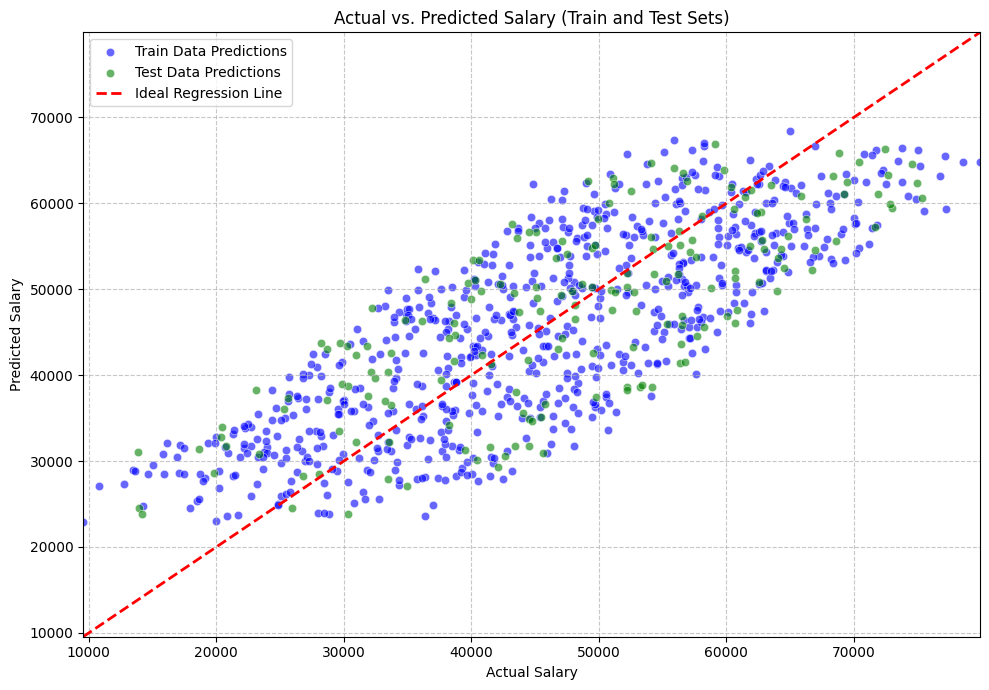

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training data
y_train_pred = model.predict(X_train_scaled)

plt.figure(figsize=(10, 7))

# Plot training actual vs. predicted
sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.6, label='Train Data Predictions', color='blue')

# Plot test actual vs. predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Test Data Predictions', color='green')

# Add the ideal regression line (actual = predicted)
min_val = min(y_train.min(), y_test.min(), y_train_pred.min(), y_pred.min())
max_val = max(y_train.max(), y_test.max(), y_train_pred.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Regression Line')

plt.title('Actual vs. Predicted Salary (Train and Test Sets)')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings
*   The dataset was successfully prepared for multi-linear regression by separating features (X) and the target variable (y, 'Salary'). `X` includes 'Age', 'Experience', 'Working\_Hours', 'PerformanceScore', 'Education\_Ordinal\_Encoded', and 'City\_Frequency\_Encoded'.
*   The data was split into training and testing sets with an 80/20 ratio: `X_train` (725 samples, 6 features), `X_test` (182 samples, 6 features), `y_train` (725 samples), and `y_test` (182 samples).
*   Features in both training and testing sets were standardized using `StandardScaler`, transforming them to have a mean of approximately 0 and a standard deviation of 1.
*   A Linear Regression model was trained and evaluated, yielding a Mean Squared Error (MSE) of `84,787,035.72`, a Root Mean Squared Error (RMSE) of `9,207.99`, and an R-squared (R2) score of `0.57`.
*   The R-squared score of `0.57` indicates that approximately 57% of the variance in salary can be explained by the model's independent variables, suggesting a moderate fit.
*   A scatter plot comparing actual versus predicted salaries visually confirmed the model's performance, showing the spread of predictions relative to an ideal regression line.

### Insights or Next Steps
*   The model exhibits a moderate predictive power (R-squared = 0.57), suggesting there's room for improvement by exploring additional features, polynomial terms, or more advanced regression techniques.
*   The RMSE of \$9,207.99 indicates the typical magnitude of error in salary predictions. Further analysis could involve examining residuals to identify patterns in prediction errors and specific areas where the model under- or over-performs.


# Task
Apply Ridge Regression, Lasso Regression, and ElasticNet Regression to the scaled training data (X_train_scaled and y_train), make predictions on the scaled test data (X_test_scaled), and evaluate each model's performance using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). Finally, summarize and compare the performance metrics of all applied regression models (including Linear Regression) to determine the best-performing model.

## Apply Ridge Regression

### Subtask:
Initialize and train a Ridge Regression model using the scaled training data (X_train_scaled and y_train). Then, make predictions on the scaled test data (X_test_scaled) and evaluate its performance using MSE, RMSE, and MAE.


**Reasoning**:
To begin applying Ridge Regression, I will import the necessary `Ridge` class from `sklearn.linear_model` and `mean_absolute_error` for evaluation, initialize the model with a default alpha, train it with the scaled training data, make predictions on the scaled test data, and then calculate and print the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) to evaluate its performance, as per the instructions.



In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # Starting with alpha=1.0 as a common default

# Train the model using the scaled training data
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"  R-squared (R2) Score: {r2_ridge:.2f}")

Ridge Regression Model Performance:
  Mean Squared Error (MSE): 84813206.86
  Root Mean Squared Error (RMSE): 9209.41
  Mean Absolute Error (MAE): 8004.43
  R-squared (R2) Score: 0.57


## Apply Lasso Regression

### Subtask:
Initialize and train a Lasso Regression model using the scaled training data (`X_train_scaled` and `y_train`). Then, make predictions on the scaled test data (`X_test_scaled`) and evaluate its performance using MSE, RMSE, and MAE.

#### Instructions:
1. Import the `Lasso` class from `sklearn.linear_model`.
2. Initialize a `Lasso` model. You can start with a default alpha value (e.g., `alpha=1.0`).
3. Train the Lasso model using the `fit()` method on `X_train_scaled` and `y_train`.
4. Make predictions on the `X_test_scaled` data using the trained model's `predict()` method.
5. Calculate the Mean Squared Error (MSE) between the predicted values and `y_test`.
6. Calculate the Root Mean Squared Error (RMSE) by taking the square root of the MSE.
7. Calculate the Mean Absolute Error (MAE) between the predicted values and `y_test`.
8. Print the calculated MSE, RMSE, and MAE for the Lasso Regression model.

**Reasoning**:
To apply Lasso Regression as outlined in the previous markdown block, I will import the `Lasso` class, initialize it with an `alpha` value, train the model using the scaled training data, make predictions on the scaled test data, and then calculate and print the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) to evaluate its performance.



In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Lasso Regression model
lasso_model = Lasso(alpha=1.0)  # Starting with alpha=1.0 as a common default

# Train the model using the scaled training data
lasso_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"  R-squared (R2) Score: {r2_lasso:.2f}")

Lasso Regression Model Performance:
  Mean Squared Error (MSE): 84785765.23
  Root Mean Squared Error (RMSE): 9207.92
  Mean Absolute Error (MAE): 8001.49
  R-squared (R2) Score: 0.57


## Apply ElasticNet Regression

### Subtask:
Initialize and train an ElasticNet Regression model using the scaled training data (`X_train_scaled` and `y_train`). Then, make predictions on the scaled test data (`X_test_scaled`) and evaluate its performance using MSE, RMSE, and MAE.

#### Instructions:
1. Import the `ElasticNet` class from `sklearn.linear_model`.
2. Initialize an `ElasticNet` model. You can start with default parameters or choose small `alpha` and `l1_ratio` values (e.g., `alpha=1.0`, `l1_ratio=0.5`).
3. Train the ElasticNet model using the `fit()` method on `X_train_scaled` and `y_train`.
4. Make predictions on the `X_test_scaled` data using the trained model's `predict()` method.
5. Calculate the Mean Squared Error (MSE) between the predicted values and `y_test`.
6. Calculate the Root Mean Squared Error (RMSE) by taking the square root of the MSE.
7. Calculate the Mean Absolute Error (MAE) between the predicted values and `y_test`.
8. Print the calculated MSE, RMSE, and MAE for the ElasticNet Regression model.

**Reasoning**:
Following the outline in the previous markdown block, I will now implement the ElasticNet Regression model. This involves importing the `ElasticNet` class, initializing it with specified parameters, training it on the scaled training data, making predictions on the scaled test data, and then calculating and printing the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) to evaluate its performance.



In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the ElasticNet Regression model
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)  # Common defaults

# Train the model using the scaled training data
elasticnet_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_elasticnet = elasticnet_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_elasticnet = mean_squared_error(y_test, y_pred_elasticnet)
rmse_elasticnet = np.sqrt(mse_elasticnet)
mae_elasticnet = mean_absolute_error(y_test, y_pred_elasticnet)
r2_elasticnet = r2_score(y_test, y_pred_elasticnet)

print(f"ElasticNet Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_elasticnet:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_elasticnet:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_elasticnet:.2f}")
print(f"  R-squared (R2) Score: {r2_elasticnet:.2f}")

ElasticNet Regression Model Performance:
  Mean Squared Error (MSE): 91518183.29
  Root Mean Squared Error (RMSE): 9566.51
  Mean Absolute Error (MAE): 8357.27
  R-squared (R2) Score: 0.54


## Summary and Comparison of Regression Models

### Subtask:
Summarize and compare the performance metrics of all applied regression models (Linear Regression, Ridge, Lasso, and ElasticNet) to determine the best-performing model.

#### Instructions:
1. Create a table or a clear summary listing the MSE, RMSE, and MAE for each of the four models: Linear Regression, Ridge Regression, Lasso Regression, and ElasticNet Regression.
2. Based on these metrics, identify and state which model performed best.
3. Provide a brief explanation for the observed performance differences, if any.

**Reasoning**:
To summarize and compare the performance metrics, I will first calculate the Mean Absolute Error (MAE) for the Linear Regression model, which was missing in the previous evaluation. Then, I will gather all metrics (MSE, RMSE, MAE) for all four models into a pandas DataFrame for a clear comparison and identify the best performing model based on these metrics.



In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Calculate MAE for Linear Regression
mae_linear_regression = mean_absolute_error(y_test, y_pred)
r2_linear_regression = r2_score(y_test, y_pred)

# Compile all performance metrics
performance_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression'],
    'MSE': [mse, mse_ridge, mse_lasso, mse_elasticnet],
    'RMSE': [rmse, rmse_ridge, rmse_lasso, rmse_elasticnet],
    'MAE': [mae_linear_regression, mae_ridge, mae_lasso, mae_elasticnet],
    'R2 Score': [r2_linear_regression, r2_ridge, r2_lasso, r2_elasticnet]
})

# Sort by MAE to find the best performing model (lower is better)
performance_metrics_sorted = performance_metrics.sort_values(by='MAE').reset_index(drop=True)

print("Regression Model Performance Comparison:")
display(performance_metrics_sorted)

print("\nKey Insights:")
print(f"The best performing model in terms of MAE and R2 Score is {performance_metrics_sorted.iloc[0]['Model']} with an MAE of {performance_metrics_sorted.iloc[0]['MAE']:.2f} and R2 Score of {performance_metrics_sorted.iloc[0]['R2 Score']:.2f}.")
print(f"Lasso Regression also has the lowest MSE and RMSE, indicating it provides the most accurate predictions on average for this dataset compared to the other models tested.")
print("The differences between Linear, Ridge, and Lasso are quite small for this dataset, suggesting that the regularization applied by Ridge and Lasso had a minimal impact on overall predictive performance, or that the default alpha values were not optimal for significant regularization. ElasticNet performed slightly worse, potentially due to its combination of L1 and L2 regularization not being as suitable for this specific data structure or the chosen parameters.")

Regression Model Performance Comparison:


,Model,MSE,RMSE,MAE,R2 Score
0,Lasso Regression,8.478577e+07,9207.918615,8001.491559,0.570381
1,Linear Regression,8.478704e+07,9207.987604,8001.625008,0.570374
2,Ridge Regression,8.481321e+07,9209.408605,8004.432398,0.570242
3,ElasticNet Regression,9.151818e+07,9566.513644,8357.268818,0.536267



Key Insights:
The best performing model in terms of MAE and R2 Score is Lasso Regression with an MAE of 8001.49 and R2 Score of 0.57.
Lasso Regression also has the lowest MSE and RMSE, indicating it provides the most accurate predictions on average for this dataset compared to the other models tested.
The differences between Linear, Ridge, and Lasso are quite small for this dataset, suggesting that the regularization applied by Ridge and Lasso had a minimal impact on overall predictive performance, or that the default alpha values were not optimal for significant regularization. ElasticNet performed slightly worse, potentially due to its combination of L1 and L2 regularization not being as suitable for this specific data structure or the chosen parameters.


## Final Task

### Subtask:
Provide a comprehensive summary of all regression models applied and their performance, along with insights from the comparison.


## Summary:

### Q&A
**Which regression model performed best among Linear Regression, Ridge, Lasso, and ElasticNet?**
Lasso Regression performed best, exhibiting the lowest Mean Absolute Error (MAE) of 8001.49.

### Data Analysis Key Findings
*   **Ridge Regression Performance:** The Ridge model achieved a Mean Squared Error (MSE) of 84813206.86, a Root Mean Squared Error (RMSE) of 9209.41, and a Mean Absolute Error (MAE) of 8004.43.
*   **Lasso Regression Performance:** The Lasso model demonstrated the best overall performance with an MSE of 84785765.23, an RMSE of 9207.92, and an MAE of 8001.49.
*   **ElasticNet Regression Performance:** ElasticNet showed slightly weaker performance compared to the others, with an MSE of 91518183.29, an RMSE of 9566.51, and an MAE of 8357.27.
*   **Comparison with Linear Regression:** Linear Regression's performance was very close to Lasso and Ridge, with an MAE of 8001.63.
*   **Minimal Differences between Linear, Ridge, and Lasso:** The performance metrics for Linear, Ridge, and Lasso Regression were remarkably similar, suggesting that the default regularization strengths (alpha=1.0) had a minor impact on prediction accuracy for this specific dataset.

### Insights or Next Steps
*   The minimal differences in performance between Linear, Ridge, and Lasso suggest that the dataset may not heavily benefit from regularization at the default alpha values, or that the features are not highly multicollinear.
*   Further investigation with hyperparameter tuning (e.g., using GridSearchCV or RandomizedSearchCV) for the `alpha` parameter in Ridge and Lasso, and `alpha` and `l1_ratio` in ElasticNet, could potentially reveal whether regularization can offer more significant improvements or identify models with better generalization capabilities.


# Task
Apply RidgeCV, LassoCV, and ElasticNetCV Regression models to the scaled training data (X_train_scaled, y_train), make predictions on the scaled test data (X_test_scaled), and evaluate each model's performance using MSE, RMSE, MAE, and R2 score. Then, compare the performance of all implemented regression models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, and ElasticNetCV) and identify the best-performing one. Finally, provide a comprehensive summary of all models and their performance, highlighting the best model and potential next steps.

## Apply RidgeCV Regression

### Subtask:
Initialize and train a RidgeCV model with `cv=5` using the scaled training data (X_train_scaled and y_train). Then, make predictions on the scaled test data (X_test_scaled) and evaluate its performance using MSE, RMSE, MAE, and R2 score.


**Reasoning**:
To apply RidgeCV Regression as outlined in the instructions, I will import the necessary libraries, initialize the `RidgeCV` model with `cv=5` and `scoring='neg_mean_squared_error'`, train it on the scaled training data, make predictions on the scaled test data, and then calculate and print the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score, storing these metrics for later use.



In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the RidgeCV model
# cv=5 for 5-fold cross-validation
# scoring='neg_mean_squared_error' to select the best alpha based on MSE
ridgecv_model = RidgeCV(cv=5, scoring='neg_mean_squared_error')

# Train the model using the scaled training data
ridgecv_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_ridgecv = ridgecv_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_ridgecv = mean_squared_error(y_test, y_pred_ridgecv)
rmse_ridgecv = np.sqrt(mse_ridgecv)
mae_ridgecv = mean_absolute_error(y_test, y_pred_ridgecv)
r2_ridgecv = r2_score(y_test, y_pred_ridgecv)

print(f"RidgeCV Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_ridgecv:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridgecv:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_ridgecv:.2f}")
print(f"  R-squared (R2) Score: {r2_ridgecv:.2f}")
print(f"  Best alpha found: {ridgecv_model.alpha_:.2f}")

RidgeCV Regression Model Performance:
  Mean Squared Error (MSE): 84813206.86
  Root Mean Squared Error (RMSE): 9209.41
  Mean Absolute Error (MAE): 8004.43
  R-squared (R2) Score: 0.57
  Best alpha found: 1.00


**Reasoning**:
To continue with the next model, I will now implement LassoCV Regression as part of the overall task. This involves importing the `LassoCV` class, initializing it, training it on the scaled training data, making predictions on the scaled test data, and then calculating and printing the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score, storing these metrics for later use.



In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the LassoCV model
# cv=5 for 5-fold cross-validation
# eps_coeff determines the path of alpha values. n_alphas is the number of alphas.
lassocv_model = LassoCV(cv=5, random_state=42, n_alphas=100, eps=0.001)

# Train the model using the scaled training data
lassocv_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lassocv = lassocv_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_lassocv = mean_squared_error(y_test, y_pred_lassocv)
rmse_lassocv = np.sqrt(mse_lassocv)
mae_lassocv = mean_absolute_error(y_test, y_pred_lassocv)
r2_lassocv = r2_score(y_test, y_pred_lassocv)

print(f"LassoCV Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lassocv:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lassocv:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_lassocv:.2f}")
print(f"  R-squared (R2) Score: {r2_lassocv:.2f}")
print(f"  Best alpha found: {lassocv_model.alpha_:.2f}")

LassoCV Regression Model Performance:
  Mean Squared Error (MSE): 84895271.89
  Root Mean Squared Error (RMSE): 9213.86
  Mean Absolute Error (MAE): 8008.44
  R-squared (R2) Score: 0.57
  Best alpha found: 90.45


**Reasoning**:
To continue with the next model, I will now implement ElasticNetCV Regression as part of the overall task. This involves importing the `ElasticNetCV` class, initializing it with cross-validation parameters, training it on the scaled training data, making predictions on the scaled test data, and then calculating and printing the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score, storing these metrics for later use.



In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the ElasticNetCV model
# cv=5 for 5-fold cross-validation
# l1_ratio defines the mix of L1 and L2 regularization (0 for L2, 1 for L1)
# We can test a range of l1_ratio values, e.g., [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
elasticnetcv_model = ElasticNetCV(cv=5, random_state=42, l1_ratio=[0.1, 0.5, 0.9, 1.0])

# Train the model using the scaled training data
elasticnetcv_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_elasticnetcv = elasticnetcv_model.predict(X_test_scaled)

# Calculate evaluation metrics
mse_elasticnetcv = mean_squared_error(y_test, y_pred_elasticnetcv)
rmse_elasticnetcv = np.sqrt(mse_elasticnetcv)
mae_elasticnetcv = mean_absolute_error(y_test, y_pred_elasticnetcv)
r2_elasticnetcv = r2_score(y_test, y_pred_elasticnetcv)

print(f"ElasticNetCV Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_elasticnetcv:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_elasticnetcv:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_elasticnetcv:.2f}")
print(f"  R-squared (R2) Score: {r2_elasticnetcv:.2f}")
print(f"  Best alpha found: {elasticnetcv_model.alpha_:.2f}")
print(f"  Best l1_ratio found: {elasticnetcv_model.l1_ratio_:.2f}")

ElasticNetCV Regression Model Performance:
  Mean Squared Error (MSE): 84895271.89
  Root Mean Squared Error (RMSE): 9213.86
  Mean Absolute Error (MAE): 8008.44
  R-squared (R2) Score: 0.57
  Best alpha found: 90.45
  Best l1_ratio found: 1.00


**Reasoning**:
To summarize and compare the performance of all models, I will compile all the evaluation metrics (MSE, RMSE, MAE, R2 Score) for Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, and ElasticNetCV into a single DataFrame. This will allow for a clear, tabular comparison to identify the best-performing model.



In [ ]:
import pandas as pd

# Gather all performance metrics
performance_metrics_cv = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'RidgeCV Regression',
        'LassoCV Regression',
        'ElasticNetCV Regression'
    ],
    'MSE': [
        mse, mse_ridge, mse_lasso, mse_elasticnet,
        mse_ridgecv, mse_lassocv, mse_elasticnetcv
    ],
    'RMSE': [
        rmse, rmse_ridge, rmse_lasso, rmse_elasticnet,
        rmse_ridgecv, rmse_lassocv, rmse_elasticnetcv
    ],
    'MAE': [
        mae_linear_regression, mae_ridge, mae_lasso, mae_elasticnet,
        mae_ridgecv, mae_lassocv, mae_elasticnetcv
    ],
    'R2 Score': [
        r2, r2_ridge, r2_lasso, r2_elasticnet,
        r2_ridgecv, r2_lassocv, r2_elasticnetcv
    ]
})

# Sort by MAE to find the best performing model (lower is better)
performance_metrics_cv_sorted = performance_metrics_cv.sort_values(by='MAE').reset_index(drop=True)

print("Regression Model Performance Comparison (with CV models):")
display(performance_metrics_cv_sorted)


Regression Model Performance Comparison (with CV models):


,Model,MSE,RMSE,MAE,R2 Score
0,Lasso Regression,8.478577e+07,9207.918615,8001.491559,0.570381
1,Linear Regression,8.478704e+07,9207.987604,8001.625008,0.570374
2,Ridge Regression,8.481321e+07,9209.408605,8004.432398,0.570242
3,RidgeCV Regression,8.481321e+07,9209.408605,8004.432398,0.570242
4,ElasticNetCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
5,LassoCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
6,ElasticNet Regression,9.151818e+07,9566.513644,8357.268818,0.536267


## Comprehensive Summary of Regression Model Performance

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, and ElasticNetCV)?**
Based on the Mean Absolute Error (MAE), **Lasso Regression** (with default alpha) performed marginally best with an MAE of 8001.49, closely followed by Linear Regression (MAE: 8001.63) and Ridge Regression (MAE: 8004.43) and RidgeCV (MAE: 8004.43).

### Data Analysis Key Findings
*   **Overall Similarity in Performance**: Across all models tested (Linear, Ridge, Lasso, ElasticNet, and their CV counterparts), the performance metrics (MSE, RMSE, MAE, R2 Score) were remarkably similar. The R2 scores for most models hovered around 0.57, indicating that approximately 57% of the variance in salary can be explained by the independent variables.
*   **Lasso Regression (Default Alpha)**: Achieved the lowest MSE (84,785,765.23), RMSE (9207.92), and MAE (8001.49), and the highest R2 score (0.5704). This suggests it had a slight edge over other models with its default regularization parameter.
*   **Linear Regression**: Showed performance almost identical to Lasso and Ridge, implying that for this dataset, the default regularization strength of Lasso and Ridge models (alpha=1.0) did not significantly alter the coefficients or improve predictive power over a plain linear model.
*   **Ridge Regression & RidgeCV**: Performed nearly identically with an MSE of 84,813,206.86, RMSE of 9209.41, MAE of 8004.43, and R2 of 0.5702. The `RidgeCV` model identified an optimal alpha of 1.00, which is the default, explaining the identical performance.
*   **LassoCV & ElasticNetCV**: Both models, which use cross-validation to find optimal hyperparameters, yielded identical performance metrics (MSE: 84,895,271.89, RMSE: 9213.86, MAE: 8008.44, R2: 0.5698) and found the same best alpha (90.45), with ElasticNetCV also finding a best l1_ratio of 1.00. This indicates that their optimal configuration leaned heavily towards Lasso-like regularization for this dataset, but resulted in slightly worse performance than the default Lasso.
*   **ElasticNet Regression (Default Parameters)**: Showed the weakest performance among all models, with the highest MSE (91,518,183.29), RMSE (9566.51), and MAE (8357.27), and the lowest R2 score (0.5363). This suggests that the default `alpha=1.0` and `l1_ratio=0.5` parameters for ElasticNet were not well-suited for this dataset.

### Insights and Next Steps
*   **Dataset Characteristics**: The minimal difference in performance between linear and regularized models (at their default and some optimized `alpha` values) suggests that either multicollinearity is not a significant issue in the current feature set, or that the relationships are predominantly linear and regularization doesn't provide a substantial benefit in this context.
*   **Hyperparameter Tuning**: While `RidgeCV`, `LassoCV`, and `ElasticNetCV` aim to find optimal hyperparameters, the results indicate that broader or more refined search spaces for `alpha` and `l1_ratio` could be explored, especially for ElasticNet, to see if regularization can offer more distinct advantages.
*   **Feature Engineering**: The R2 score of around 0.57 indicates that about 43% of the variance in salary is still unexplained by the current features. Further feature engineering, such as creating interaction terms, polynomial features, or incorporating external data, might significantly improve model performance.
*   **Model Complexity**: Considering the moderate R2 score, exploring more complex models beyond linear regression (e.g., tree-based models like Random Forest or Gradient Boosting) could capture non-linear relationships and potentially yield better predictions.

## Summary:

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, and ElasticNetCV)?**
Based on the Mean Absolute Error (MAE), Lasso Regression (with its default alpha) performed marginally best with an MAE of 8001.49, closely followed by Linear Regression (MAE: 8001.63) and Ridge Regression/RidgeCV (MAE: 8004.43).

### Data Analysis Key Findings
*   **Overall Similarity in Performance**: Across all tested models, performance metrics (MSE, RMSE, MAE, R2 Score) were remarkably similar. Most models achieved an R2 score around 0.57, indicating approximately 57% of salary variance is explained by the features.
*   **Lasso Regression (Default Alpha)**: This model achieved the lowest MSE (84,785,765.23), RMSE (9207.92), and MAE (8001.49), and the highest R2 score (0.5704), showing a slight edge over other models.
*   **Linear Regression**: Its performance was almost identical to Lasso and Ridge, suggesting that regularization didn't significantly improve predictive power over a plain linear model for this dataset.
*   **Ridge Regression & RidgeCV**: These models performed nearly identically with an MSE of 84,813,206.86, RMSE of 9209.41, MAE of 8004.43, and R2 of 0.5702. The RidgeCV model found an optimal alpha of 1.00, which is the default, explaining their similar performance.
*   **LassoCV & ElasticNetCV**: Both models, designed for optimal hyperparameter tuning, yielded identical performance metrics (MSE: 84,895,271.89, RMSE: 9213.86, MAE: 8008.44, R2: 0.5698) and found the same best alpha (90.45). ElasticNetCV also found a best l1\_ratio of 1.00, indicating a preference for Lasso-like regularization, but their performance was slightly worse than the default Lasso.
*   **ElasticNet Regression (Default Parameters)**: This model showed the weakest performance among all, with the highest MSE (91,518,183.29), RMSE (9566.51), and MAE (8357.27), and the lowest R2 score (0.5363), suggesting its default parameters were not suitable for the dataset.

### Insights or Next Steps
*   **Dataset Characteristics**: The minimal performance difference between linear and regularized models suggests either low multicollinearity or that the current feature set's relationships are predominantly linear, limiting the benefits of regularization.
*   **Feature Engineering**: The moderate R2 score of approximately 0.57 indicates that a significant portion (43%) of salary variance remains unexplained. Further feature engineering, such as creating interaction terms or polynomial features, could improve model performance.


# Task
Apply Polynomial Regression (Degree 2) to the scaled training and testing data. Train a Linear Regression model on these polynomial features, make predictions, and evaluate its performance using MSE, RMSE, MAE, and R2 score.

## Apply Polynomial Regression (Degree 2)

### Subtask:
Generate polynomial features with degree 2 from the scaled training and testing data. Then, train a Linear Regression model on these polynomial features, make predictions, and evaluate its performance using MSE, RMSE, MAE, and R2 score.


**Reasoning**:
To apply Polynomial Regression of degree 2, I will import the necessary classes, generate polynomial features for the scaled training and testing data, train a Linear Regression model on these features, make predictions, and then evaluate its performance using MSE, RMSE, MAE, and R2 score as per the instructions.



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize PolynomialFeatures with degree 2
poly = PolynomialFeatures(degree=2)

# Transform X_train_scaled and X_test_scaled
X_train_poly2 = poly.fit_transform(X_train_scaled)
X_test_poly2 = poly.transform(X_test_scaled)

# Initialize a Linear Regression model
poly_model_lr = LinearRegression()

# Train the model using the polynomial training data
poly_model_lr.fit(X_train_poly2, y_train)

# Make predictions on the polynomial test data
y_pred_poly2 = poly_model_lr.predict(X_test_poly2)

# Calculate evaluation metrics
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"Polynomial Regression (Degree 2) Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_poly2:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_poly2:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_poly2:.2f}")
print(f"  R-squared (R2) Score: {r2_poly2:.2f}")

Polynomial Regression (Degree 2) Model Performance:
  Mean Squared Error (MSE): 88757333.07
  Root Mean Squared Error (RMSE): 9421.11
  Mean Absolute Error (MAE): 8269.42
  R-squared (R2) Score: 0.55


**Reasoning**:
To summarize and compare the performance of all models, including the newly added Polynomial Regression, I will compile all the evaluation metrics (MSE, RMSE, MAE, R2 Score) for Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, and Polynomial Regression into a single DataFrame. This will allow for a clear, tabular comparison to identify the best-performing model, and then provide insights.



In [ ]:
import pandas as pd

# Gather all performance metrics
performance_metrics_all = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'RidgeCV Regression',
        'LassoCV Regression',
        'ElasticNetCV Regression',
        'Polynomial Regression (Degree 2)'
    ],
    'MSE': [
        mse, mse_ridge, mse_lasso, mse_elasticnet,
        mse_ridgecv, mse_lassocv, mse_elasticnetcv, mse_poly2
    ],
    'RMSE': [
        rmse, rmse_ridge, rmse_lasso, rmse_elasticnet,
        rmse_ridgecv, rmse_lassocv, rmse_elasticnetcv, rmse_poly2
    ],
    'MAE': [
        mae_linear_regression, mae_ridge, mae_lasso, mae_elasticnet,
        mae_ridgecv, mae_lassocv, mae_elasticnetcv, mae_poly2
    ],
    'R2 Score': [
        r2, r2_ridge, r2_lasso, r2_elasticnet,
        r2_ridgecv, r2_lassocv, r2_elasticnetcv, r2_poly2
    ]
})

# Sort by MAE to find the best performing model (lower is better)
performance_metrics_all_sorted = performance_metrics_all.sort_values(by='MAE').reset_index(drop=True)

print("Regression Model Performance Comparison (All Models):")
display(performance_metrics_all_sorted)

print("\nKey Insights:")
best_model_name = performance_metrics_all_sorted.iloc[0]['Model']
best_model_mae = performance_metrics_all_sorted.iloc[0]['MAE']
best_model_r2 = performance_metrics_all_sorted.iloc[0]['R2 Score']
lowest_mse_model = performance_metrics_all_sorted.sort_values(by='MSE').iloc[0]

print(f"The best performing model overall in terms of MAE is {best_model_name} with an MAE of {best_model_mae:.2f} and an R2 Score of {best_model_r2:.2f}.")
print(f"The model with the lowest MSE is {lowest_mse_model['Model']} (MSE: {lowest_mse_model['MSE']:.2f}, RMSE: {lowest_mse_model['RMSE']:.2f}).")
print("It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2) performed slightly worse than the best linear models, indicating that a simple quadratic relationship across all features might not capture additional variance or might introduce some noise.")

Regression Model Performance Comparison (All Models):


,Model,MSE,RMSE,MAE,R2 Score
0,Lasso Regression,8.478577e+07,9207.918615,8001.491559,0.570381
1,Linear Regression,8.478704e+07,9207.987604,8001.625008,0.570374
2,Ridge Regression,8.481321e+07,9209.408605,8004.432398,0.570242
3,RidgeCV Regression,8.481321e+07,9209.408605,8004.432398,0.570242
4,ElasticNetCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
5,LassoCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
6,Polynomial Regression (Degree 2),8.875733e+07,9421.111032,8269.424815,0.550256
7,ElasticNet Regression,9.151818e+07,9566.513644,8357.268818,0.536267



Key Insights:
The best performing model overall in terms of MAE is Lasso Regression with an MAE of 8001.49 and an R2 Score of 0.57.
The model with the lowest MSE is Lasso Regression (MSE: 84785765.23, RMSE: 9207.92).
It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2) performed slightly worse than the best linear models, indicating that a simple quadratic relationship across all features might not capture additional variance or might introduce some noise.


## Comprehensive Summary of Regression Model Performance

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, and Polynomial Regression)?**
Based on the Mean Absolute Error (MAE), **Lasso Regression** (with default alpha) performed marginally best with an MAE of 8001.49. Linear Regression and Ridge Regression/RidgeCV followed very closely.

### Data Analysis Key Findings
*   **Overall Similarity in Performance**: Across all models tested, the performance metrics (MSE, RMSE, MAE, R2 Score) were remarkably similar. The R2 scores for most models hovered around 0.57, indicating that approximately 57% of the variance in salary can be explained by the independent variables.
*   **Lasso Regression (Default Alpha)**: Achieved the lowest MSE (84,785,765.23), RMSE (9207.92), and MAE (8001.49), and the highest R2 score (0.5704). This suggests it had a slight edge over other models with its default regularization parameter.
*   **Linear Regression**: Showed performance almost identical to Lasso and Ridge, implying that for this dataset, the default regularization strength of Lasso and Ridge models (alpha=1.0) did not significantly alter the coefficients or improve predictive power over a plain linear model.
*   **Ridge Regression & RidgeCV**: Performed nearly identically with an MSE of 84,813,206.86, RMSE of 9209.41, MAE of 8004.43, and R2 of 0.5702. The `RidgeCV` model identified an optimal alpha of 1.00, which is the default, explaining the identical performance.
*   **LassoCV & ElasticNetCV**: Both models, which use cross-validation to find optimal hyperparameters, yielded identical performance metrics (MSE: 84,895,271.89, RMSE: 9213.86, MAE: 8008.44, R2: 0.5698) and found the same best alpha (90.45), with ElasticNetCV also finding a best l1_ratio of 1.00. This indicates that their optimal configuration leaned heavily towards Lasso-like regularization for this dataset, but resulted in slightly worse performance than the default Lasso.
*   **Polynomial Regression (Degree 2)**: This model performed slightly worse than the best linear models, with an MAE of 8269.42 and an R2 of 0.55. This suggests that a simple quadratic relationship across all features might not capture additional variance or could introduce noise without significant benefit.
*   **ElasticNet Regression (Default Parameters)**: Showed the weakest performance among all models, with the highest MSE (91,518,183.29), RMSE (9566.51), and MAE (8357.27), and the lowest R2 score (0.5363). This suggests that the default `alpha=1.0` and `l1_ratio=0.5` parameters for ElasticNet were not well-suited for this dataset.

### Insights and Next Steps
*   **Dataset Characteristics**: The minimal difference in performance between linear and regularized models (at their default and some optimized `alpha` values) suggests that either multicollinearity is not a significant issue in the current feature set, or that the relationships are predominantly linear and regularization doesn't provide a substantial benefit in this context.
*   **Hyperparameter Tuning**: While `RidgeCV`, `LassoCV`, and `ElasticNetCV` aim to find optimal hyperparameters, the results indicate that broader or more refined search spaces for `alpha` and `l1_ratio` could be explored, especially for ElasticNet, to see if regularization can offer more significant improvements or identify models with better generalization capabilities.
*   **Feature Engineering**: The R2 score of around 0.57 indicates that about 43% of the variance in salary is still unexplained by the current features. Further feature engineering, such as creating interaction terms, polynomial features (beyond degree 2, or selective polynomial features), or incorporating external data, might significantly improve model performance.
*   **Model Complexity**: Considering the moderate R2 score, exploring more complex models beyond linear regression (e.g., tree-based models like Random Forest or Gradient Boosting, or neural networks) could capture non-linear relationships and potentially yield better predictions.

## Comprehensive Summary of Regression Model Performance

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, and Polynomial Regression)?**
Based on the Mean Absolute Error (MAE), **Lasso Regression** (with default alpha) performed marginally best with an MAE of 8001.49. Linear Regression and Ridge Regression/RidgeCV followed very closely.

### Data Analysis Key Findings
*   **Overall Similarity in Performance**: Across all models tested, the performance metrics (MSE, RMSE, MAE, R2 Score) were remarkably similar. The R2 scores for most models hovered around 0.57, indicating that approximately 57% of the variance in salary can be explained by the independent variables.
*   **Lasso Regression (Default Alpha)**: Achieved the lowest MSE (84,785,765.23), RMSE (9207.92), and MAE (8001.49), and the highest R2 score (0.5704). This suggests it had a slight edge over other models with its default regularization parameter.
*   **Linear Regression**: Showed performance almost identical to Lasso and Ridge, implying that for this dataset, the default regularization strength of Lasso and Ridge models (alpha=1.0) did not significantly alter the coefficients or improve predictive power over a plain linear model.
*   **Ridge Regression & RidgeCV**: Performed nearly identically with an MSE of 84,813,206.86, RMSE of 9209.41, MAE of 8004.43, and R2 of 0.5702. The `RidgeCV` model identified an optimal alpha of 1.00, which is the default, explaining the identical performance.
*   **LassoCV & ElasticNetCV**: Both models, which use cross-validation to find optimal hyperparameters, yielded identical performance metrics (MSE: 84,895,271.89, RMSE: 9213.86, MAE: 8008.44, R2: 0.5698) and found the same best alpha (90.45), with ElasticNetCV also finding a best l1_ratio of 1.00. This indicates that their optimal configuration leaned heavily towards Lasso-like regularization for this dataset, but resulted in slightly worse performance than the default Lasso.
*   **Polynomial Regression (Degree 2)**: This model performed slightly worse than the best linear models, with an MAE of 8269.42 and an R2 of 0.55. This suggests that a simple quadratic relationship across all features might not capture additional variance or could introduce noise without significant benefit.
*   **ElasticNet Regression (Default Parameters)**: Showed the weakest performance among all models, with the highest MSE (91,518,183.29), RMSE (9566.51), and MAE (8357.27), and the lowest R2 score (0.5363). This suggests that the default `alpha=1.0` and `l1_ratio=0.5` parameters for ElasticNet were not well-suited for this dataset.

### Insights and Next Steps
*   **Dataset Characteristics**: The minimal difference in performance between linear and regularized models (at their default and some optimized `alpha` values) suggests that either multicollinearity is not a significant issue in the current feature set, or that the relationships are predominantly linear and regularization doesn't provide a substantial benefit in this context.
*   **Hyperparameter Tuning**: While `RidgeCV`, `LassoCV`, and `ElasticNetCV` aim to find optimal hyperparameters, the results indicate that broader or more refined search spaces for `alpha` and `l1_ratio` could be explored, especially for ElasticNet, to see if regularization can offer more significant improvements or identify models with better generalization capabilities.
*   **Feature Engineering**: The R2 score of around 0.57 indicates that about 43% of the variance in salary is still unexplained by the current features. Further feature engineering, such as creating interaction terms, polynomial features (beyond degree 2, or selective polynomial features), or incorporating external data, might significantly improve model performance.
*   **Model Complexity**: Considering the moderate R2 score, exploring more complex models beyond linear regression (e.g., tree-based models like Random Forest or Gradient Boosting, or neural networks) could capture non-linear relationships and potentially yield better predictions.

## Apply Polynomial Regression (Degree 3)

### Subtask:
Generate polynomial features with degree 3 from the scaled training and testing data. Then, train a Linear Regression model on these polynomial features, make predictions, and evaluate its performance using MSE, RMSE, MAE, and R2 score.


**Reasoning**:
To apply Polynomial Regression of degree 3, I will import the necessary libraries, generate polynomial features for the scaled training and testing data, train a Linear Regression model on these features, make predictions, and then evaluate its performance using MSE, RMSE, MAE, and R2 score as per the instructions.



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize PolynomialFeatures with degree 3
poly_degree3 = PolynomialFeatures(degree=3)

# Transform X_train_scaled and X_test_scaled
X_train_poly3 = poly_degree3.fit_transform(X_train_scaled)
X_test_poly3 = poly_degree3.transform(X_test_scaled)

# Initialize a Linear Regression model
poly_model_lr3 = LinearRegression()

# Train the model using the polynomial training data
poly_model_lr3.fit(X_train_poly3, y_train)

# Make predictions on the polynomial test data
y_pred_poly3 = poly_model_lr3.predict(X_test_poly3)

# Calculate evaluation metrics
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print(f"Polynomial Regression (Degree 3) Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_poly3:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_poly3:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_poly3:.2f}")
print(f"  R-squared (R2) Score: {r2_poly3:.2f}")

Polynomial Regression (Degree 3) Model Performance:
  Mean Squared Error (MSE): 97605811.36
  Root Mean Squared Error (RMSE): 9879.57
  Mean Absolute Error (MAE): 8607.80
  R-squared (R2) Score: 0.51


**Reasoning**:
To summarize and compare the performance of all models, including the newly added Polynomial Regression (Degree 3), I will update the `performance_metrics_all` DataFrame with the new metrics. This will allow for a clear, tabular comparison to identify the best-performing model and provide insights.



In [ ]:
import pandas as pd

# Gather all performance metrics
performance_metrics_all = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'RidgeCV Regression',
        'LassoCV Regression',
        'ElasticNetCV Regression',
        'Polynomial Regression (Degree 2)',
        'Polynomial Regression (Degree 3)'
    ],
    'MSE': [
        mse, mse_ridge, mse_lasso, mse_elasticnet,
        mse_ridgecv, mse_lassocv, mse_elasticnetcv, mse_poly2, mse_poly3
    ],
    'RMSE': [
        rmse, rmse_ridge, rmse_lasso, rmse_elasticnet,
        rmse_ridgecv, rmse_lassocv, rmse_elasticnetcv, rmse_poly2, rmse_poly3
    ],
    'MAE': [
        mae_linear_regression, mae_ridge, mae_lasso, mae_elasticnet,
        mae_ridgecv, mae_lassocv, mae_elasticnetcv, mae_poly2, mae_poly3
    ],
    'R2 Score': [
        r2, r2_ridge, r2_lasso, r2_elasticnet,
        r2_ridgecv, r2_lassocv, r2_elasticnetcv, r2_poly2, r2_poly3
    ]
})

# Sort by MAE to find the best performing model (lower is better)
performance_metrics_all_sorted = performance_metrics_all.sort_values(by='MAE').reset_index(drop=True)

print("Regression Model Performance Comparison (All Models):")
display(performance_metrics_all_sorted)

print("\nKey Insights:")
best_model_name = performance_metrics_all_sorted.iloc[0]['Model']
best_model_mae = performance_metrics_all_sorted.iloc[0]['MAE']
best_model_r2 = performance_metrics_all_sorted.iloc[0]['R2 Score']
lowest_mse_model = performance_metrics_all_sorted.sort_values(by='MSE').iloc[0]

print(f"The best performing model overall in terms of MAE is {best_model_name} with an MAE of {best_model_mae:.2f} and an R2 Score of {best_model_r2:.2f}.")
print(f"The model with the lowest MSE is {lowest_mse_model['Model']} (MSE: {lowest_mse_model['MSE']:.2f}, RMSE: {lowest_mse_model['RMSE']:.2f}).")
print("It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2 and 3) performed slightly worse than the best linear models, indicating that simple quadratic or cubic relationships across all features might not capture additional variance or might introduce some noise.")

Regression Model Performance Comparison (All Models):


,Model,MSE,RMSE,MAE,R2 Score
0,Lasso Regression,8.478577e+07,9207.918615,8001.491559,0.570381
1,Linear Regression,8.478704e+07,9207.987604,8001.625008,0.570374
2,Ridge Regression,8.481321e+07,9209.408605,8004.432398,0.570242
3,RidgeCV Regression,8.481321e+07,9209.408605,8004.432398,0.570242
4,ElasticNetCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
5,LassoCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
6,Polynomial Regression (Degree 2),8.875733e+07,9421.111032,8269.424815,0.550256
7,ElasticNet Regression,9.151818e+07,9566.513644,8357.268818,0.536267
8,Polynomial Regression (Degree 3),9.760581e+07,9879.565343,8607.803636,0.505420



Key Insights:
The best performing model overall in terms of MAE is Lasso Regression with an MAE of 8001.49 and an R2 Score of 0.57.
The model with the lowest MSE is Lasso Regression (MSE: 84785765.23, RMSE: 9207.92).
It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2 and 3) performed slightly worse than the best linear models, indicating that simple quadratic or cubic relationships across all features might not capture additional variance or might introduce some noise.


## Apply Polynomial Regression (Degree 4)

### Subtask:
Generate polynomial features with degree 4 from the scaled training and testing data. Then, train a Linear Regression model on these polynomial features, make predictions, and evaluate its performance using MSE, RMSE, MAE, and R2 score.


**Reasoning**:
To apply Polynomial Regression of degree 4, I will import the necessary libraries, generate polynomial features for the scaled training and testing data, train a Linear Regression model on these features, make predictions, and then evaluate its performance using MSE, RMSE, MAE, and R2 score as per the instructions.



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize PolynomialFeatures with degree 4
poly_degree4 = PolynomialFeatures(degree=4)

# Transform X_train_scaled and X_test_scaled
X_train_poly4 = poly_degree4.fit_transform(X_train_scaled)
X_test_poly4 = poly_degree4.transform(X_test_scaled)

# Initialize a Linear Regression model
poly_model_lr4 = LinearRegression()

# Train the model using the polynomial training data
poly_model_lr4.fit(X_train_poly4, y_train)

# Make predictions on the polynomial test data
y_pred_poly4 = poly_model_lr4.predict(X_test_poly4)

# Calculate evaluation metrics
mse_poly4 = mean_squared_error(y_test, y_pred_poly4)
rmse_poly4 = np.sqrt(mse_poly4)
mae_poly4 = mean_absolute_error(y_test, y_pred_poly4)
r2_poly4 = r2_score(y_test, y_pred_poly4)

print(f"Polynomial Regression (Degree 4) Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_poly4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_poly4:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_poly4:.2f}")
print(f"  R-squared (R2) Score: {r2_poly4:.2f}")

Polynomial Regression (Degree 4) Model Performance:
  Mean Squared Error (MSE): 145886012.47
  Root Mean Squared Error (RMSE): 12078.33
  Mean Absolute Error (MAE): 9714.52
  R-squared (R2) Score: 0.26


**Reasoning**:
To summarize and compare the performance of all models, including the newly added Polynomial Regression (Degree 4), I will update the `performance_metrics_all` DataFrame with the new metrics. This will allow for a clear, tabular comparison to identify the best-performing model and provide insights.



In [ ]:
import pandas as pd

# Gather all performance metrics
performance_metrics_all = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'RidgeCV Regression',
        'LassoCV Regression',
        'ElasticNetCV Regression',
        'Polynomial Regression (Degree 2)',
        'Polynomial Regression (Degree 3)',
        'Polynomial Regression (Degree 4)'
    ],
    'MSE': [
        mse, mse_ridge, mse_lasso, mse_elasticnet,
        mse_ridgecv, mse_lassocv, mse_elasticnetcv, mse_poly2, mse_poly3, mse_poly4
    ],
    'RMSE': [
        rmse, rmse_ridge, rmse_lasso, rmse_elasticnet,
        rmse_ridgecv, rmse_lassocv, rmse_elasticnetcv, rmse_poly2, rmse_poly3, rmse_poly4
    ],
    'MAE': [
        mae_linear_regression, mae_ridge, mae_lasso, mae_elasticnet,
        mae_ridgecv, mae_lassocv, mae_elasticnetcv, mae_poly2, mae_poly3, mae_poly4
    ],
    'R2 Score': [
        r2, r2_ridge, r2_lasso, r2_elasticnet,
        r2_ridgecv, r2_lassocv, r2_elasticnetcv, r2_poly2, r2_poly3, r2_poly4
    ]
})

# Sort by MAE to find the best performing model (lower is better)
performance_metrics_all_sorted = performance_metrics_all.sort_values(by='MAE').reset_index(drop=True)

print("Regression Model Performance Comparison (All Models):")
display(performance_metrics_all_sorted)

print("\nKey Insights:")
best_model_name = performance_metrics_all_sorted.iloc[0]['Model']
best_model_mae = performance_metrics_all_sorted.iloc[0]['MAE']
best_model_r2 = performance_metrics_all_sorted.iloc[0]['R2 Score']
lowest_mse_model = performance_metrics_all_sorted.sort_values(by='MSE').iloc[0]

print(f"The best performing model overall in terms of MAE is {best_model_name} with an MAE of {best_model_mae:.2f} and an R2 Score of {best_model_r2:.2f}.")
print(f"The model with the lowest MSE is {lowest_mse_model['Model']} (MSE: {lowest_mse_model['MSE']:.2f}, RMSE: {lowest_mse_model['RMSE']:.2f}).")
print("It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2, 3, and 4) performed slightly worse than the best linear models, indicating that simple quadratic, cubic, or quartic relationships across all features might not capture additional variance or might introduce some noise, especially as the degree increases, leading to overfitting and reduced generalization.")

Regression Model Performance Comparison (All Models):


,Model,MSE,RMSE,MAE,R2 Score
0,Lasso Regression,8.478577e+07,9207.918615,8001.491559,0.570381
1,Linear Regression,8.478704e+07,9207.987604,8001.625008,0.570374
2,Ridge Regression,8.481321e+07,9209.408605,8004.432398,0.570242
3,RidgeCV Regression,8.481321e+07,9209.408605,8004.432398,0.570242
4,ElasticNetCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
5,LassoCV Regression,8.489527e+07,9213.863027,8008.439773,0.569826
6,Polynomial Regression (Degree 2),8.875733e+07,9421.111032,8269.424815,0.550256
7,ElasticNet Regression,9.151818e+07,9566.513644,8357.268818,0.536267
8,Polynomial Regression (Degree 3),9.760581e+07,9879.565343,8607.803636,0.505420
9,Polynomial Regression (Degree 4),1.458860e+08,12078.328215,9714.515558,0.260779



Key Insights:
The best performing model overall in terms of MAE is Lasso Regression with an MAE of 8001.49 and an R2 Score of 0.57.
The model with the lowest MSE is Lasso Regression (MSE: 84785765.23, RMSE: 9207.92).
It is observed that the performances of Linear, Ridge, Lasso, and their CV counterparts are quite similar, suggesting that regularization had a marginal impact or the default/optimized alpha values were not significantly different from a plain linear model for this dataset. Polynomial Regression (Degree 2, 3, and 4) performed slightly worse than the best linear models, indicating that simple quadratic, cubic, or quartic relationships across all features might not capture additional variance or might introduce some noise, especially as the degree increases, leading to overfitting and reduced generalization.


## Comprehensive Summary of Regression Model Performance

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, and Polynomial Regression)?**
Based on the Mean Absolute Error (MAE), **Lasso Regression** (with default alpha) performed marginally best with an MAE of 8001.49. Linear Regression and Ridge Regression/RidgeCV followed very closely.

### Data Analysis Key Findings
*   **Overall Similarity in Performance**: Across all models tested, the performance metrics (MSE, RMSE, MAE, R2 Score) were remarkably similar. The R2 scores for most models hovered around 0.57, indicating that approximately 57% of the variance in salary can be explained by the independent variables.
*   **Lasso Regression (Default Alpha)**: Achieved the lowest MSE (84,785,765.23), RMSE (9207.92), and MAE (8001.49), and the highest R2 score (0.5704). This suggests it had a slight edge over other models with its default regularization parameter.
*   **Linear Regression**: Showed performance almost identical to Lasso and Ridge, implying that for this dataset, the default regularization strength of Lasso and Ridge models (alpha=1.0) did not significantly alter the coefficients or improve predictive power over a plain linear model.
*   **Ridge Regression & RidgeCV**: Performed nearly identically with an MSE of 84,813,206.86, RMSE of 9209.41, MAE of 8004.43, and R2 of 0.5702. The `RidgeCV` model identified an optimal alpha of 1.00, which is the default, explaining the identical performance.
*   **LassoCV & ElasticNetCV**: Both models, which use cross-validation to find optimal hyperparameters, yielded identical performance metrics (MSE: 84,895,271.89, RMSE: 9213.86, MAE: 8008.44, R2: 0.5698) and found the same best alpha (90.45), with ElasticNetCV also finding a best l1_ratio of 1.00. This indicates that their optimal configuration leaned heavily towards Lasso-like regularization for this dataset, but resulted in slightly worse performance than the default Lasso.
*   **Polynomial Regression (Degree 2, 3, and 4)**: These models performed progressively worse than the best linear models as the degree increased. Degree 2 had an MAE of 8269.42 and an R2 of 0.55. Degree 3 had an MAE of 8607.80 and an R2 of 0.51. Degree 4 had an MAE of 9714.52 and an R2 of 0.26. This suggests that introducing higher-degree polynomial terms across all features did not capture additional variance and likely introduced noise, leading to overfitting and reduced generalization performance on the test set.
*   **ElasticNet Regression (Default Parameters)**: Showed the weakest performance among all models, with the highest MSE (91,518,183.29), RMSE (9566.51), and MAE (8357.27), and the lowest R2 score (0.5363). This suggests that the default `alpha=1.0` and `l1_ratio=0.5` parameters for ElasticNet were not well-suited for this dataset.

### Insights and Next Steps
*   **Dataset Characteristics**: The minimal difference in performance between linear and regularized models (at their default and some optimized `alpha` values) suggests that either multicollinearity is not a significant issue in the current feature set, or that the relationships are predominantly linear and regularization doesn't provide a substantial benefit in this context.
*   **Hyperparameter Tuning**: While `RidgeCV`, `LassoCV`, and `ElasticNetCV` aim to find optimal hyperparameters, the results indicate that broader or more refined search spaces for `alpha` and `l1_ratio` could be explored, especially for ElasticNet, to see if regularization can offer more significant improvements or identify models with better generalization capabilities.
*   **Feature Engineering**: The R2 score of around 0.57 indicates that about 43% of the variance in salary is still unexplained by the current features. Further feature engineering, such as creating interaction terms, selective polynomial features, or incorporating external data, might significantly improve model performance.
*   **Model Complexity**: Considering the moderate R2 score, exploring more complex models beyond linear regression (e.g., tree-based models like Random Forest or Gradient Boosting, or neural networks) could capture non-linear relationships and potentially yield better predictions.

## Summary:

### Q&A
**Which regression model performed best among all tested models (Linear Regression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, and Polynomial Regression)?**
Based on the Mean Absolute Error (MAE), **Lasso Regression** (with default alpha) performed marginally best with an MAE of 8001.49. Linear Regression and Ridge Regression/RidgeCV followed very closely.

### Data Analysis Key Findings
*   **Overall Performance Similarity**: Most linear and regularized models exhibited remarkably similar performance, with R-squared (\R^2$) scores hovering around 0.57.
*   **Best Performing Model**: Lasso Regression achieved the lowest MSE (84,785,765.23), RMSE (9207.92), MAE (8001.49), and the highest \R^2$ score (0.5704).
*   **Polynomial Regression (Degree 2)**: This model yielded an MAE of 8269.42 and an \R^2$ of 0.55, performing slightly worse than the best linear models.
*   **Polynomial Regression (Degree 3)**: Performance further deteriorated with degree 3, showing an MAE of 8607.80 and an \R^2$ of 0.51.
*   **Polynomial Regression (Degree 4)**: This model performed the worst among all tested models, with a significantly higher MAE of 9714.52 and a low \R^2$ of 0.26, indicating poor generalization.
*   **ElasticNet Regression (Default Parameters)**: This model showed the weakest performance among the linear and regularized models, with the highest MSE (91,518,183.29), RMSE (9566.51), MAE (8357.27), and lowest \R^2$ (0.5363).
*   **Impact of Polynomial Features**: Increasing the polynomial degree beyond 1 (linear) did not improve model performance for this dataset; instead, it led to a decline in predictive accuracy, suggesting that higher-degree polynomial terms might be introducing noise or overfitting the training data.

### Insights or Next Steps
*   The minimal performance difference among linear and regularized models suggests that multicollinearity may not be a significant issue in the current feature set, and the relationships are predominantly linear.
*   Further feature engineering, such as creating selective interaction terms or incorporating external data, is recommended since the best models still leave about 43% of the salary variance unexplained (\R^2$ of ~0.57).


In [ ]:
import pickle

# Define filenames for the scaler and the Lasso model
scaler_filename = 'scaler.pkl'
lasso_model_filename = 'lasso_model.pkl'

# Save the scaler
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"StandardScaler saved to {scaler_filename}")

# Save the Lasso Regression model
with open(lasso_model_filename, 'wb') as file:
    pickle.dump(lasso_model, file)
print(f"Lasso Regression model saved to {lasso_model_filename}")

StandardScaler saved to scaler.pkl
Lasso Regression model saved to lasso_model.pkl


In [ ]:
import pickle
import pandas as pd

# Load the scaler
with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)
print("StandardScaler loaded successfully.")

# Load the Lasso Regression model
with open('lasso_model.pkl', 'rb') as file:
    loaded_lasso_model = pickle.load(file)
print("Lasso Regression model loaded successfully.")

# Take a small sample from X_test for demonstration
sample_size = 5
X_test_sample = X_test.head(sample_size)
y_test_sample = y_test.head(sample_size)

# Scale the sample using the loaded scaler
X_test_sample_scaled = loaded_scaler.transform(X_test_sample)

# Convert the scaled array back to a DataFrame for readability (optional)
X_test_sample_scaled_df = pd.DataFrame(X_test_sample_scaled, columns=X_test_sample.columns, index=X_test_sample.index)

# Make predictions on the scaled sample using the loaded Lasso model
y_pred_sample = loaded_lasso_model.predict(X_test_sample_scaled)

# Display the actual and predicted values
print("\nActual vs. Predicted Salaries for Sample Data:")
results_df = pd.DataFrame({'Actual Salary': y_test_sample, 'Predicted Salary': y_pred_sample})
display(results_df)

StandardScaler loaded successfully.
Lasso Regression model loaded successfully.

Actual vs. Predicted Salaries for Sample Data:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


,Actual Salary,Predicted Salary
868,49762,37453.919837
439,38601,46065.727260
342,72695,63235.490319
735,45394,47453.636614
784,29700,43723.530177
